<br>
<div align="center">
  <img src="imagens/marca assinatura hor col png.png" alt="Logo" width="300">
</div>

<h1 align="center"> Trabalho 1 (T1) </h1>

<h1 align="center">Análise Multivariada da Demanda Energética<br>e sua Relação com Variáveis Climáticas e Matriz de Geração</h1>

<br> 

**Tema:** monitoramento e análise de carga elétrica e de condições meteorológicas a partir de medições reais na Espanha

**Base utilizada:** *Hourly energy demand generation and weather: Electrical demand, generation by type, prices and weather in Spain*

**Fonte:** https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather


# Referência da base

> Jhana, N. (2019). *Hourly energy demand generation and weather* [Conjunto de dados]. repositório oficial Kaggle. https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather



# Justificativas da escolha da base de dados

  - É uma base real de dados, não são dados simulados.</li>
  - É um assunto relacionado a área do curso de Engenharia Elétrica.</li>
  - Possui variáveis fisicamente interpretáveis.</li>
  - É uma base de dados extensa o que nos permite trabalhar com leitura de dados, estatística exploratória e visualização de gráficos, que são essenciais para a dinâmica da disciplina.</li>
  - A geração energética é dada de diversas fontes, renováveis e não renováveis, que compõem a matriz energética da Espanha.</li>

  
  


# Limitações

- Parte dos dados contém valores ausentes, algumas colunas são compostas majoritariamente por zeros e há linhas repetidas, o que nos exige fazer o tratamento desses dados.</li>
- Apesar de se tratar de uma base real de dados, é necessário analisar criticamente e estatisticamente os conjuntos de dados a fim de garantir a consistência real e física dos valores dados.</li>
- Os dados meteorológicos são de 5 grandes cidades espanholas distantes entre si, limitando a captação de características climáticas de regiões rurais ou industriais que podem também impactar a demanda nacional.</li>
- A cobertura temporal é limitada, de 2015 a 2018, o que pode não refletir mudanças recentes na matriz energética espanhola.</li>





# Integrantes do grupo
* Aluno 1 — Gabriel Assunção Rios
* Aluno 2 — João Ewerton Santos Paixão
* Aluno 3 — Marcos Paulo da Silva

# Repositório do grupo

https://github.com/marcospsilv/Trabalho_1_Machine_Learning

# Convenção de cores para identificar contribuições

* <span style="color:green">**Verde**</span>: Gabriel Assunção Rios
* <span style="color:blue">**Azul**</span>: João Ewerton Santos Paixão
* <span style="color:red">**Vermelho**</span>: Marcos Paulo da Silva

# 1. Definição do problema

O presente trabalho tem como objetivo analisar o comportamento da geração/consumo e do preço de energia elétrica ao longo do tempo, buscando identificar padrões, relações e possíveis influências entre variáveis como carga total, temperatura e preço. O problema central consiste em compreender como essas variáveis se correlacionam e em que medida fatores externos, como condições climáticas, impactam a demanda e o custo da energia elétrica. A análise de geração/consumo é fundamental para:
- identificação de padrões de uso;
- planejamento energético;
- análise de previsão de consumo;
- previsão de preços.

Nesta base de dados, temos dados de geração e previsão de energia elétrica na Espanha, com resolução de 1 hora, entre janeiro de 2015 até dezembro de 2018, obtidos do [ENTSOE, um portal público](https://transparency.entsoe.eu/) de dados de Operadores de Sistemas de Transmissão (TSO) e do [TSO espanhol Red Elétrica de España](https://www.ree.es/). As variáveis incluem geração de biomassa, geração por carvão marrom, geração por gás derivado do carvão, geração por gás fóssil, geração por carvão mineral (hulha), geração por petróleo, geração por xisto betuminoso, geração por turfa, geração geotérmica, geração hidrelétrica por armazenamento bombeado(total), Consumo no bombeamento de água (hidrelétrica reversível), geração hidrelétrica a fio d’água, geração hidrelétrica de reservatório, geração por energia marinha, geração nuclear, outras fontes de geração, outras fontes renováveis, geração solar, geração a partir de resíduos, geração eólica offshore (no mar), geração eólica onshore (em terra).


Além destes, temos também dados meteorológicos de cinco das maiores cidades da Espanha: Madri, Bilbau, Valência, Barcelona e Sevilha. Os dados são de temperatura, pressão atmosférica, velocidade do vento, humidade do ar, volume de chuva e volume de neve e foram adquiridos como parte de um projeto pessoal da [Open Weather API](https://openweathermap.org/api).

Apesar da disponibilidade de dados de somente cinco cidades espanholas, é possível inferir que estes dados são suficientes para as análises que serão realizadas nesse trabalho, uma vez que a distribuição geográfica dessas cinco cidades cobre grande parte do território espanhol, como é possível observar na Figura 1, que apresenta em vermelho as províncias em que essas cinco cidades se localizam.

<div style="text-align: center;">
  <p id="figura_mapa"><b>Figura 1: Localização das províncias em que se encontram Madri, Bilbau, Valência, Barcelona e Sevilha</b></p>
  <img src="imagens/MapChart_Map.png" width="900px">
  <br>
  <small><i>Fonte: Elaborado pelo autor (2026) com uso do portal <a href="https://www.mapchart.net/spain.html" target="_blank">Map Chart</a>.</i></small>
</div>

Objetivos específicos:
- descrever a base de dados;
- tratar valores ausentes de forma tecnicamente ajustável;
- tratar valores inconsistentes fisicamente;
- investigar as distribuições e relações entre variáveis e entre os conjuntos de dados;
- discutir diferentes formas estatísticas;
- criar gráficos para visualização;
- propor como a base pode ser usada em um problema futuro de aprendizado de máquinas.




<div style="color: red;">

# 2. Leitura e Organização dos Dados

</div>

<div style="color: red;">
    
De início, é necessário importar as bibliotecas *Python* que serão utilizadas no trabalho e ler os conjuntos de dados de energia e de condições climáticas.

</div>


In [1]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import os

In [2]:
# Lendo os dados em .csv

# Dados de energia
dataframe_energia = pd.read_csv("energy_dataset.csv", parse_dates=["time"]) # parse_dates faz o pandas tratar a primeira coluna como valores de datas reais

# Dados de condições climáticas
dataframe_clima = pd.read_csv("weather_features.csv", parse_dates=["dt_iso"]) # parse_dates faz o pandas tratar a primeira coluna como valores de datas reais

# Criando cópias dos dois dataframes para que não seja necessário carregá-los novamente em casos de alterações indevidas
df_energia = dataframe_energia.copy()
df_clima = dataframe_clima.copy()

<div style="color: red;">
    
### 2.1. Conjunto de dados de energia
Este conjunto contém os dados de geração de energia de diversas fontes na Espanha. Fontes como biomassa, carvão, combustíveis fósseis e solar, por exemplo, são apresentadas ao longo de 4 anos, hora a hora.
Além disso, são apresentados dados reais de demanda de eletricidade e do preço da energia e dados de previsão de geração solar e eólica e de demanda de eletricidade no dia seguinte.

</div>

In [3]:
print(f"Início: {df_energia['time'].min()}") # Exibindo o instante inicial da aquisição de dados
print(f"Fim:    {df_energia['time'].max()}") # Exibindo o instante final da aquisição de dados
df_energia.head(5) # Exibindo as 5 primeiras linhas dos dados de energia

Início: 2015-01-01 00:00:00+01:00
Fim:    2018-12-31 23:00:00+01:00


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [4]:
# Conferindo se há inconsistências nos tipos de variáveis
df_energia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [5]:
# Convertendo o tempo "time" para um objeto de "tempo de dados" e definindo como índice

#to_datetime → 
df_energia['time'] = pd.to_datetime(df_energia['time'], utc=True)
df_energia = df_energia.set_index('time')

# Conferindo se a conversão da coluna de tempo funcionou
df_energia.info()

df_energia.head(5)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil coal-derived gas           35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation fossil oil shale                  35046 non-null  float64
 7   generation fossil peat                       35046 non-null  float64
 8   generation geothermal                        35046 non-null  float64
 9   generation hydro pumped s

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


<div style="color: red;">

#### 2.1.1. Identificação e tratamento de variáveis irrelevantes

É necessário conferir se existem colunas compostas somente por valores nulos (_NaN_), somente por zeros ou majoritariamente por zeros. Neste último caso, foi considerado que uma coluna é composta majoritariamente por zeros se ela apresenta mais de 99% dos valores iguais a zero.

Colunas que possuem somente valores nulos ou valores iguais a zero serão descartadas, pois serão inúteis nas análises e no aprendizado de máquina futuro. Já as colunas compostas majoritariamente por zeros também serão descartadas, porque elas podem causar instabilidades numéricas no treinamento em algoritmos lineares e em redes neurais (KUHN; JOHNSON, 2019).

</div>

In [6]:
# Conferindo quais colunas apresentam somente valores nulos (NaN)

# df_energia.columns → contém a lista de todas as colunas do DF
# isnull() → confere se cada célula é ou não é nula
# all() → analisa se TODAS as células de uma coluna é nula
# tolist() → converte o objeto em lista comum para exibição
totalmente_nulas = df_energia.columns[df_energia.isnull().all()].tolist()

print(f"– Colunas com 100% de valores nulos (NaN): {totalmente_nulas}")

# 1. Identificando quais colunas têm apenas o valor 0
colunas_so_zero = df_energia.columns[(df_energia == 0).all()].tolist()

print(f"  ")
print(f"– Colunas que contêm apenas zeros: {colunas_so_zero}")


# Conferindo quais colunas apresentam mais de 95% dos valores iguais a zero (0)

# Calculando a proporção de zeros em cada coluna
proporcao_zeros = (df_energia == 0).mean()

# Filtrando colunas que têm mais de 95% de zeros
colunas_muitos_zeros = proporcao_zeros[proporcao_zeros > 0.99].index.tolist()

print(f"  ")
print(f"– Colunas com mais de 99% de valores iguais a zero (0): {colunas_muitos_zeros}")

– Colunas com 100% de valores nulos (NaN): ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']
  
– Colunas que contêm apenas zeros: []
  
– Colunas com mais de 99% de valores iguais a zero (0): ['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation marine', 'generation wind offshore']


In [7]:
# Descartando as colunas "inúteis"

# Combinando as três listas em uma só
# set() → cria um conjunto evitando possíveis duplicidades
colunas_para_remover = list(set(totalmente_nulas + colunas_so_zero + colunas_muitos_zeros))

# Removendo as colunas do conjuntos de dados de energia
# drop → remove linhas ou colunas de um dataframe
# 'errors=ignore' → é uma segurança extra caso uma coluna já tenha sido removida
df_energia = df_energia.drop(columns=colunas_para_remover, errors='ignore')

# Exibindo o resultado da limpeza
print(f"– Limpeza concluída!")
print(f"– Total de colunas removidas: {len(colunas_para_remover)}")
print(f"– Colunas restantes no DataFrame: {df_energia.shape[1]}")

– Limpeza concluída!
– Total de colunas removidas: 8
– Colunas restantes no DataFrame: 20


<div style="color: red;">
    
Ademais, as colunas que possuem dados de predição ("_forecast_") de carga total, energia solar e energia eólica serão descartadas, pois são irrelevantes para as análises realizadas nesse trabalho.

</div>

In [8]:
# Descartando as colunas de predição

# axis=1 == axis=columns → remove colunas
df_energia = df_energia.drop(['total load forecast', 'forecast solar day ahead',
                            'forecast wind onshore day ahead'], axis=1)

# Exibindo o resultado da limpeza
print(f"Limpeza concluída!")
print(f"Colunas restantes no DataFrame: {df_energia.shape[1]}")

Limpeza concluída!
Colunas restantes no DataFrame: 17


In [9]:
# Informações sobre o dataframe de dados de energia
df_energia.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 17 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil gas                        35046 non-null  float64
 3   generation fossil hard coal                  35046 non-null  float64
 4   generation fossil oil                        35045 non-null  float64
 5   generation hydro pumped storage consumption  35045 non-null  float64
 6   generation hydro run-of-river and poundage   35045 non-null  float64
 7   generation hydro water reservoir             35046 non-null  float64
 8   generation nuclear                           35047 non-null  float64
 9   generation other         

<div style="color: red;">
    
#### 2.1.2. Tratamento de valores ausentes (NaNs) e de linhas duplicadas
Para limpeza dos dados, precisa-se conferir se há linhas duplicadas e valores ausentes no conjunto de dados de energia.

</div>


In [10]:
# Contando os nulos em cada coluna

# isnull() → identifica se o valor é NaN
# sum() → soma a quantidade de nulos por coluna
nulos_por_coluna = df_energia.isnull().sum()

# Exibindo as colunas que possuem pelo menos um valor nulo
print("– Quantidade de NaNs por coluna:")
print(nulos_por_coluna[nulos_por_coluna > 0])

# Exibindo o valor total de valores nulos no dataframe de energia

# .sum().sum() → soma primeiro a quantidade de nulos por coluna e depois soma o número de nulos por coluna
total_geral_nulos = df_energia.isnull().sum().sum()
print(f"   ")
print(f"– Total de valores nulos no DataFrame: {total_geral_nulos}")

# Conferindo se há linhas duplicadas

# duplicated() → confere se a linha é igual à linha anterior
total_duplicadas = df_energia.duplicated().sum()
print(f"   ")
print(f"– Há {total_duplicadas} linhas duplicadas nas colunas.")

– Quantidade de NaNs por coluna:
generation biomass                             19
generation fossil brown coal/lignite           18
generation fossil gas                          18
generation fossil hard coal                    18
generation fossil oil                          19
generation hydro pumped storage consumption    19
generation hydro run-of-river and poundage     19
generation hydro water reservoir               18
generation nuclear                             17
generation other                               18
generation other renewable                     18
generation solar                               18
generation waste                               19
generation wind onshore                        18
total load actual                              36
dtype: int64
   
– Total de valores nulos no DataFrame: 292
   
– Há 0 linhas duplicadas nas colunas.


<div style="color: red;">
    
Há alguns valores ausentes nos dados de energia e, como os dados são uma série temporal, não é possível simplesmente descartar as linhas que possuem valores ausentes. Para resolver esse problema, optou-se por estimar os dados ausentes através de interpolação linear.

In [11]:
# Preenchendo os valores ausentes utilizando interpolação linear

# .interpolate() → método de interpolação para preencher valores ausentes
# inplace=True → substituí o dataframe "original" pelo novo dataframe com os NaNs preenchidos
df_energia.interpolate(method='linear', inplace=True, axis=0)

# Conferindo se todos os valores ausentes foram preenchidos
total_geral_nulos = df_energia.isnull().sum().sum()
print(f"   ")
print(f"– Total de valores nulos no DataFrame: {total_geral_nulos}")

   
– Total de valores nulos no DataFrame: 0


In [12]:
df_energia.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00,35064.00
mean,383.53,448.09,5622.70,4256.53,298.34,475.58,972.20,2605.53,6263.48,60.23,85.63,1432.82,269.42,5464.98,28698.28,49.87,57.88
std,85.35,354.62,2201.51,1961.99,52.52,792.31,400.71,1835.18,840.27,20.24,14.08,1679.96,50.22,3213.59,4575.83,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,2.06,9.33
25%,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1078.00,5759.00,53.00,73.00,71.00,240.00,2933.00,24807.00,41.49,49.35
50%,367.00,509.00,4969.50,4475.00,300.00,68.00,906.00,2165.00,6564.00,57.00,88.00,616.00,279.00,4849.50,28902.00,50.52,58.02
75%,433.00,757.00,6429.00,5839.00,330.00,616.00,1250.00,3758.00,7025.00,80.00,97.00,2579.00,310.00,7399.50,32194.25,60.53,68.01
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,106.00,119.00,5792.00,357.00,17436.00,41015.00,101.99,116.80


<div style="color: red;">
    
### 2.2. Conjunto de dados de condições meteorológicas
Este conjunto contém dados meteorológicos, como temperatura, pressão atmosférica, umidade e velocidade do vento, hora a hora ao longo de quatro anos em cinco grandes cidades espanholas: Valência, Madri, Bilbau, Barcelona e Sevilha.

Como os dados meteorológicos foram obtidos através do [OpenWeather](https://openweathermap.org/), os dados de temperatura são dados em Kelvin (K), os dados de pressão são dados em hectopascais (hPa), a umidade é dada em porcentagem relativa (%), a velocidade do vento é dada em metros por segundo (m/s), a direção do vento é dada em graus (°), os volumes de chuva e de neve são dados em milímetros (mm) e a cobertura de nuvens é dada em percentual de nebulosidade.

In [13]:
# Gerando uma lista das cidades presentes no conjunto de dados
cidades = df_clima['city_name'].unique().tolist()

print(f"– Cidades presentes no conjunto de dados:{cidades}")
print(f"  ")
print(f"Início: {df_clima['dt_iso'].min()}") # Exibindo o instante inicial da aquisição de dados
print(f"Fim:    {df_clima['dt_iso'].max()}") # Exibindo o instante final da aquisição de dados
print(f"  ")
df_clima.head(5)

– Cidades presentes no conjunto de dados:['Valencia', 'Madrid', 'Bilbao', ' Barcelona', 'Seville']
  
Início: 2015-01-01 00:00:00+01:00
Fim:    2018-12-31 23:00:00+01:00
  


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [14]:
# Conferindo se há inconsistências nos tipos de variáveis
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

<div style="color: red;">

É necessário que todas as colunas numéricas possuam o mesmo tipo de variável, logo as colunas com valores inteiros (_int64_) são convertidas para _float64_.

In [15]:
# Alterando as colunas com tipo int64 para float64
# Seleciona colunas inteiras e as converte
# Seleciona automaticamente tudo que for número inteiro e converte
df_clima = df_clima.astype({col: 'float64' for col in df_clima.select_dtypes('int64').columns})

df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  float64
 6   humidity             178396 non-null  float64
 7   wind_speed           178396 non-null  float64
 8   wind_deg             178396 non-null  float64
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  float64
 13  weather_id           178396 non-null  float64
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [16]:
# Convertendo o tempo "time" para um objeto de "tempo de dados" e definindo como índice

#to_datetime →
df_clima['time'] = pd.to_datetime(df_clima['dt_iso'], utc=True)
df_clima = df_clima.set_index('time')

df_clima.head(5)

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
time,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n
2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,800.0,clear,sky is clear,01n


<div style="color: red;">
    
#### 2.2.1. Identificação e tratamento de variáveis irrelevantes

Assim como foi feito com o conjunto de dados de energia, as colunas compostas somente por valores nulos(_NaN_), somente por zeros ou majoritariamente por zeros devem ser desacartadas.

In [17]:
# Conferindo quais colunas apresentam somente valores nulos (NaN)

# df_energia.columns → contém a lista de todas as colunas do DF
# isnull() → confere se cada célula é ou não é nula
# all() → analisa se TODAS as células de uma coluna é nula
# tolist() → converte o objeto em lista comum para exibição
totalmente_nulas = df_clima.columns[df_clima.isnull().all()].tolist()

print(f"– Colunas com 100% de valores nulos (NaN): {totalmente_nulas}")

# 1. Identificando quais colunas têm apenas o valor 0
colunas_so_zero = df_clima.columns[(df_clima == 0).all()].tolist()

print(f"  ")
print(f"– Colunas que contêm apenas zeros: {colunas_so_zero}")


# Conferindo quais colunas apresentam mais de 95% dos valores iguais a zero (0)

# Calculando a proporção de zeros em cada coluna
proporcao_zeros = (df_clima == 0).mean()

# Filtrando colunas que têm mais de 95% de zeros
colunas_muitos_zeros = proporcao_zeros[proporcao_zeros > 0.95].index.tolist()

print(f"  ")
print(f"– Colunas com mais de 95% de valores iguais a zero (0): {colunas_muitos_zeros}")

– Colunas com 100% de valores nulos (NaN): []
  
– Colunas que contêm apenas zeros: []
  
– Colunas com mais de 95% de valores iguais a zero (0): ['rain_3h', 'snow_3h']


In [18]:
df_clima.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
count,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00,178396.00
mean,289.62,288.33,291.09,1069.26,68.42,2.47,166.59,0.08,0.00,0.00,25.07,759.83
std,8.03,7.96,8.61,5969.63,21.90,2.10,116.61,0.40,0.01,0.22,30.77,108.73
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,200.00
25%,283.67,282.48,284.65,1013.00,53.00,1.00,55.00,0.00,0.00,0.00,0.00,800.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,177.00,0.00,0.00,0.00,20.00,800.00
75%,295.15,293.73,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00,801.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00,804.00


<div style="color: red;">

No que diz respeito à coluna "snow_3h", optou-se por sua permanência no conjunto de dados devido ao seu possível impacto direto na demanda energética, já que a ocorrência de neve está relacionada a quedas bruscas de temperatura e, consequentemente, mudanças no comportamento de consumo. Vale mencionar que o desvio padrão (std) de "snow_3h" é baixo, porém relativamente próximo do desvio padrão de "rain_1h", indicando sua possível relevância nas análises deste trabalho.

<div style="color: red;">

Além disso, as colunas que possuem informações climáticas qualitativas serão descartadas.

In [19]:
# Descartando as colunas com informações de clima qualitativas
df_clima = df_clima.drop(['weather_main', 'weather_id', 
                              'weather_description', 'weather_icon'], axis=1)

# Exibindo o resultado da limpeza
print(f"Limpeza concluída!")
print(f"Colunas restantes no DataFrame: {df_clima.shape[1]}")

Limpeza concluída!
Colunas restantes no DataFrame: 13


<div style="color: red;">
    
#### 2.2.2. Tratamento de valores ausentes (NaNs) e de linhas duplicadas
Para limpeza dos dados, precisa-se conferir se há linhas duplicadas e valores ausentes no conjunto de dados meteorológicos.



In [20]:

# Contando os nulos em cada coluna

# isnull() → identifica se o valor é NaN
# sum() → soma a quantidade de nulos por coluna
nulos_por_coluna = df_clima.isnull().sum()

# Exibindo as colunas que possuem pelo menos um valor nulo
print("– Quantidade de NaNs por coluna:")
print(nulos_por_coluna[nulos_por_coluna > 0])

# Exibindo o valor total de valores nulos no dataframe de energia

# .sum().sum() → soma primeiro a quantidade de nulos por coluna e depois soma o número de nulos por coluna
total_geral_nulos = df_clima.isnull().sum().sum()
print(f"   ")
print(f"– Total de valores nulos no DataFrame: {total_geral_nulos}")

# Conferindo se há linhas duplicadas

# duplicated() → confere se a linha é igual à linha anterior
total_duplicadas = df_clima.duplicated().sum()
print(f"   ")
print(f"– Há {total_duplicadas} linhas duplicadas nas colunas.")

– Quantidade de NaNs por coluna:
Series([], dtype: int64)
   
– Total de valores nulos no DataFrame: 0
   
– Há 3076 linhas duplicadas nas colunas.


<div style="color: red;">

Nesse caso, não há valores ausentes nos dados. Entretanto, há 21 linhas duplicadas que devem ser descartadas.

In [21]:
# Descartando as linhas duplicadas
df_clima_2 = df_clima.drop_duplicates(inplace=True)

In [22]:
# Conferindo se as linhas repetidas foram descartadas

# duplicated() → confere se a linha é igual à linha anterior
total_duplicadas = df_clima.duplicated().sum()
print(f"   ")
print(f"– Há {total_duplicadas} linhas duplicadas nas colunas.")

   
– Há 0 linhas duplicadas nas colunas.


<div style="color: red;">

#### 2.2.3. Tratamento de inconsistências

In [23]:
df_clima.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
count,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00
mean,289.71,288.43,291.17,1070.20,68.03,2.47,166.72,0.07,0.00,0.00,24.34
std,8.02,7.95,8.61,6021.77,21.84,2.10,116.55,0.39,0.01,0.22,30.34
min,262.24,262.24,262.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,283.83,282.78,284.91,1013.00,53.00,1.00,56.00,0.00,0.00,0.00,0.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,178.00,0.00,0.00,0.00,16.00
75%,295.24,294.15,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00
max,315.60,315.15,321.15,1008371.00,100.00,133.00,360.00,12.00,2.32,21.50,100.00


<div style="color: red;">

O resumo estatístico do conjunto de dados meteorológicos apresenta algumas inconsistências graves:

<ul>
  <li><b>Pressão:</b> há o registro de valor mínimo de 0 hPa e valor máximo de 1.000.000 hPa. De acordo com a <a href="https://www.aemet.es/es/serviciosclimaticos/datos_climatologicos/valores_extremos" style="color: red;" target="_blank">Agência Estatal de Meteorologia (AEMET)</a>, a menor pressão já registrada na Espanha foi de aproximadamente 950 hPa e a maior de 1.050 hPa.</li>
  
  <li><b>Velocidade do vento:</b> o valor máximo registrado é de 133 m/s. Segundo a <a href="https://www.aemet.es/es/serviciosclimaticos/datos_climatologicos/valores_extremos" style="color: red;" target="_blank">Agência Estatal de Meteorologia (AEMET)</a>, o recorde nacional é de 248 km/h ($ \approx 68,89$ m/s), o que indica que os valores acima desse limiar no dataset são erros de medição.</li>
  
  <li><b>Chuvas:</b> os dados de <i>"rain_3h"</i> apresentam valores máximos inferiores aos de <i>"rain_1h"</i>. Fisicamente, isso é um erro lógico, pois o acumulado de 3 horas deveria, obrigatoriamente, ser igual ou superior ao acumulado de 1 hora contido no mesmo intervalo.</li>
</ul>

</div>

<Axes: xlabel='pressure'>

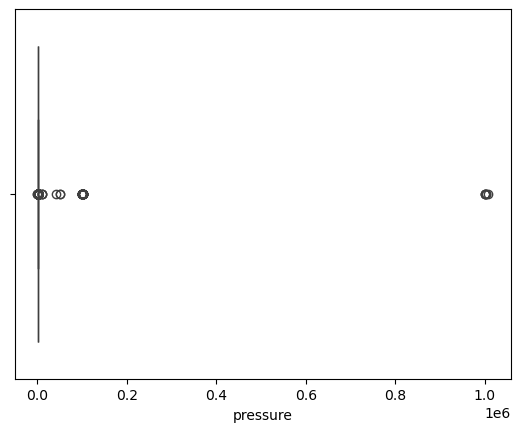

In [24]:
# Exibindo os valores inconsistentes na coluna de pressão

sns.boxplot(x=df_clima['pressure'])


<div style="color: red;">

De modo a tratar esses dados, optou-se por definir como limiar os recordes mínimo e máximo de pressão atmosférica na Espanhe e máximo de velocidade do vento, interpolando linearmente os dados de medição fora desses limiares.

In [25]:
# Definindo como NaN os valores fora do intervalo
df_clima.loc[(df_clima['pressure'] < 950), 'pressure'] = np.nan
df_clima.loc[(df_clima['pressure'] > 1050), 'pressure'] = np.nan

In [26]:
# Realiza a interpolação e salva na coluna
df_clima['pressure'] = df_clima['pressure'].interpolate(method='linear')

<Axes: xlabel='pressure'>

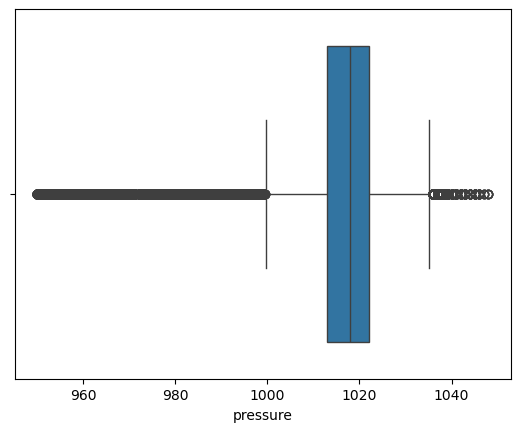

In [27]:
# Conferindo a correção na coluna de pressão atmosférica

sns.boxplot(x=df_clima['pressure'])



<Axes: xlabel='wind_speed'>

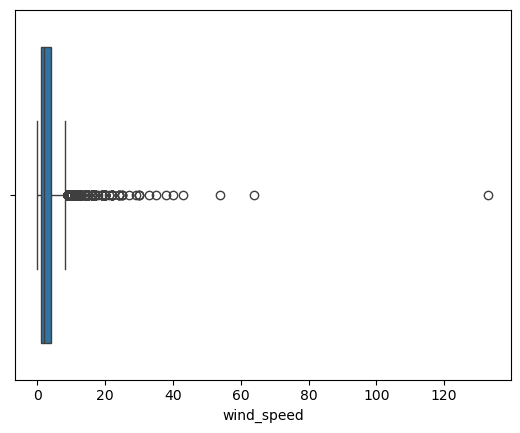

In [28]:
# Exibindo os valores inconsistentes na coluna de velocidade do vento wind_speed

sns.boxplot(x=df_clima['wind_speed'])


In [29]:
# Filtrando as velocidades do vento acima de 68,89 m/s
df_clima.loc[(df_clima['wind_speed'] > 68.89), 'wind_speed'] = np.nan

# Realiza a interpolação e salva na coluna
df_clima['wind_speed'] = df_clima['wind_speed'].interpolate(method='linear')


<Axes: xlabel='wind_speed'>

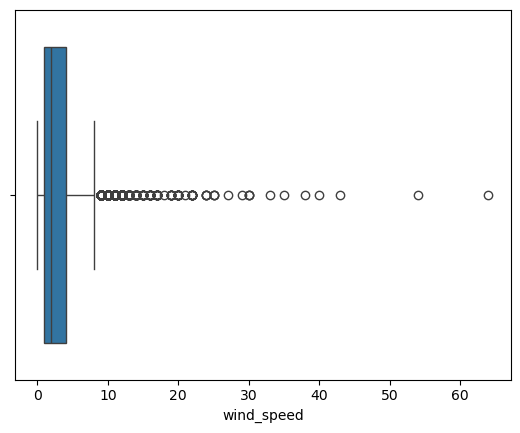

In [30]:
# Conferindo a correção na coluna de velocidade do vento

sns.boxplot(x=df_clima['wind_speed'])

<div style="color: red;">

Para corrigir o erro de medição na coluna de chuva nas últimas 3 horas ("rain_3h"), a coluna foi refeita somando-se repetidamente os últimos 3 dados da coluna "rain_3h".

In [31]:
# 2. Cria a nova coluna baseada na soma móvel das últimas 3 horas de rain_1h
df_clima['rain_3h_corrigida'] = df_clima['rain_1h'].rolling(window=3, min_periods=1).sum()

# 3. Vamos comparar as duas colunas para ver a diferença
print(df_clima[['rain_1h', 'rain_3h', 'rain_3h_corrigida']].describe())

             rain_1h        rain_3h  rain_3h_corrigida
count  175320.000000  175320.000000      175320.000000
mean        0.069308       0.000386           0.207923
std         0.385915       0.007348           0.977268
min         0.000000       0.000000           0.000000
25%         0.000000       0.000000           0.000000
50%         0.000000       0.000000           0.000000
75%         0.000000       0.000000           0.000000
max        12.000000       2.315000          36.000000


In [32]:
# 1. Deleta a coluna original que estava com erro
df_clima.drop(columns=['rain_3h'], inplace=True)

# 2. Renomeia a coluna corrigida para o nome original
df_clima.rename(columns={'rain_3h_corrigida': 'rain_3h'}, inplace=True)

In [33]:
df_clima.head(5)

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,snow_3h,clouds_all,rain_3h
time,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0


In [34]:
# 1. Pegamos a lista atual de colunas
cols = list(df_clima.columns)

# 2. Removemos a 'rain_3h' da posição atual dela
cols.remove('rain_3h')

# 3. Encontramos a posição da 'rain_1h' e inserimos a 'rain_3h' logo depois (pos + 1)
pos_rain1h = cols.index('rain_1h')
cols.insert(pos_rain1h + 1, 'rain_3h')

# 4. Reaplicamos a nova ordem ao DataFrame
df_clima = df_clima[cols]

df_clima.head(10)

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
time,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0
2015-01-01 04:00:00+00:00,2015-01-01 05:00:00+01:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0
2015-01-01 05:00:00+00:00,2015-01-01 06:00:00+01:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0
2015-01-01 06:00:00+00:00,2015-01-01 07:00:00+01:00,Valencia,270.292,270.292,270.292,1004.0,71.0,2.0,321.0,0.0,0.0,0.0,0.0
2015-01-01 07:00:00+00:00,2015-01-01 08:00:00+01:00,Valencia,274.601,274.601,274.601,1005.0,71.0,1.0,307.0,0.0,0.0,0.0,0.0


In [35]:
df_clima.describe().round(2)

,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
count,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00,175320.00
mean,289.71,288.43,291.17,1016.20,68.03,2.47,166.72,0.07,0.21,0.00,24.34
std,8.02,7.95,8.61,11.59,21.84,2.07,116.55,0.39,0.98,0.22,30.34
min,262.24,262.24,262.24,950.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,283.83,282.78,284.91,1013.00,53.00,1.00,56.00,0.00,0.00,0.00,0.00
50%,289.15,288.15,290.15,1018.00,72.00,2.00,178.00,0.00,0.00,0.00,16.00
75%,295.24,294.15,297.15,1022.00,87.00,4.00,270.00,0.00,0.00,0.00,40.00
max,315.60,315.15,321.15,1048.00,100.00,64.00,360.00,12.00,36.00,21.50,100.00


<div style="color: red;">
    
&nbsp;
#### 2.2.4. Separando o dataframe em cinco dataframes, um por cidade

In [36]:
cidades = df_clima['city_name'].unique()
df_clima_porcidade = df_clima.groupby('city_name')

In [37]:
df_clima_porcidade.head(2)

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
time,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Valencia,270.475000,270.475000,270.475000,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Valencia,270.475000,270.475000,270.475000,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Madrid,267.325000,267.325000,267.325000,971.0,63.0,1.0,309.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Madrid,267.325000,267.325000,267.325000,971.0,63.0,1.0,309.0,0.0,0.0,0.0,0.0
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Bilbao,269.657312,269.657312,269.657312,1036.0,97.0,0.0,226.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Bilbao,269.763500,269.763500,269.763500,1035.0,97.0,0.0,229.0,0.0,0.0,0.0,0.0
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Barcelona,281.625000,281.625000,281.625000,1035.0,100.0,7.0,58.0,0.0,0.0,0.0,0.0
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Barcelona,281.625000,281.625000,281.625000,1035.0,100.0,7.0,58.0,0.0,0.0,0.0,0.0
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Seville,273.375000,273.375000,273.375000,1039.0,75.0,1.0,21.0,0.0,0.0,0.0,0.0


In [38]:
# Conferindo se há a mesma quantidade de dados para cada cidade

for city in cidades:
    print('There are {} observations in df_weather'
          .format(df_clima_porcidade.get_group('{}'.format(city)).shape[0]),
          'about city: {}.'.format(city))

There are 35064 observations in df_weather about city: Valencia.
There are 35064 observations in df_weather about city: Madrid.
There are 35064 observations in df_weather about city: Bilbao.
There are 35064 observations in df_weather about city:  Barcelona.
There are 35064 observations in df_weather about city: Seville.


<div style="color: green;">

# 3. Análise estatística exploratória

<div style="color: green;">

## 3.1 Medidas de tendência central

<div style="color: green;">

#### Dados energia

<div style="color: green;">

#### Definição das medias de interesse
- Count(contagem): quantidade de valores válidos
- Mean(média): valor médio dos dados
- Std(desvio padrão): mede a dispersão dos dados em relação à média
- Min(mínimo): mínimo valor observado
- 25%(primeiro quartil): 25% dos dados estão abaixo desse valor
- 50%(segundo quartil ou mediana): valor central dos dados
- 75%(terceiro quartil): 755 dos dados estão abaixo desse valor
- max(máximo): máximo valor observado
- variancia: mede a dispersão dos dados(desvio padrão ao quadrado)
- assimetria(skewness): mede se os dados são simétricos ou inclinado

≈ 0 → distribuição simétrica

maior que 0 → cauda para a direita (valores altos raros)

menor que 0 → cauda para a esquerda

- curtose: mede o "formato" da distribuição(pico e caudas)

≈ 0 → distribuição normal

maior que 0 → muitos valores extremos (caudas pesadas)

menor que 0 → dados mais “achatados”




In [39]:

# Seleciona apenas as colunas numéricas do DataFrame
num_cols = df_energia.select_dtypes(include=['number'])

# Gera as estatísticas descritivas básicas (média, desvio padrão, quartis, etc.)
descricao = num_cols.describe()

# Adiciona a variância (dispersão dos dados)
descricao.loc['variancia'] = num_cols.var()

# Adiciona a assimetria (skewness) - indica a inclinação da distribuição
descricao.loc['assimetria'] = num_cols.skew()

# Adiciona a curtose (kurtosis) - indica o achatamento da distribuição
descricao.loc['curtose'] = num_cols.kurtosis()

# Exibe a tabela detalhada
display(descricao)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual
count,35064.000000,35064.000000,3.506400e+04,3.506400e+04,35064.000000,35064.000000,35064.000000,3.506400e+04,35064.000000,35064.000000,35064.000000,3.506400e+04,35064.000000,3.506400e+04,3.506400e+04,35064.000000,35064.000000
mean,383.531343,448.094570,5.622701e+03,4.256531e+03,298.342417,475.582706,972.201902,2.605534e+03,6263.483430,60.226030,85.634326,1.432819e+03,269.418692,5.464980e+03,2.869828e+04,49.874341,57.884023
std,85.346266,354.618269,2.201511e+03,1.961989e+03,52.519927,792.312704,400.712304,1.835175e+03,840.272333,20.238792,14.076948,1.679962e+03,50.218423,3.213586e+03,4.575829e+03,14.618900,14.204083
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,1.804100e+04,2.060000,9.330000
25%,333.000000,0.000000,4.126000e+03,2.527000e+03,263.000000,0.000000,637.000000,1.078000e+03,5759.000000,53.000000,73.000000,7.100000e+01,240.000000,2.933000e+03,2.480700e+04,41.490000,49.347500
50%,367.000000,509.000000,4.969500e+03,4.475000e+03,300.000000,68.000000,906.000000,2.165000e+03,6564.000000,57.000000,88.000000,6.160000e+02,279.000000,4.849500e+03,2.890200e+04,50.520000,58.020000
75%,433.000000,757.000000,6.429000e+03,5.839000e+03,330.000000,616.000000,1250.000000,3.758000e+03,7025.000000,80.000000,97.000000,2.579000e+03,310.000000,7.399500e+03,3.219425e+04,60.530000,68.010000
max,592.000000,999.000000,2.003400e+04,8.359000e+03,449.000000,4523.000000,2000.000000,9.728000e+03,7117.000000,106.000000,119.000000,5.792000e+03,357.000000,1.743600e+04,4.101500e+04,101.990000,116.800000
variancia,7283.985053,125754.116841,4.846651e+06,3.849401e+06,2758.342733,627759.421085,160570.350672,3.367868e+06,706057.593654,409.608698,198.160457,2.822271e+06,2521.889989,1.032714e+07,2.093821e+07,213.712228,201.755982
assimetria,0.420732,-0.046831,1.615403e+00,-7.321122e-02,0.063861,2.130311,0.500356,8.966902e-01,-0.693318,-0.505454,-0.215354,1.020121e+00,-0.848498,7.844055e-01,6.171446e-02,-0.487771,-0.323749


<div style="color: green;">

#### Análise descritiva:
#### Comportamento da carga
- A Assimetria (0.06) é quase zero. Isto indica que a carga elétrica na Espanha distribui-se de forma muito equilibrada em torno da média (~28.698 MW). A Curtose (-0.91) é negativa. Isto significa que a curva de carga é "platicúrtica" (mais achatada que uma normal). Na prática, isto nos diz que o consumo não varia de forma caótica; ele tem patamares bem definidos (o nível de consumo de dia e o nível de noite).
#### Comportamento do preço
- A média é 57.88 e a mediana (50%) é 58.02. Como estão muito próximas, confirma-se a baixa assimetria.A Curtose (0.46) é positiva, ao contrário da carga. Isto indica que o preço tem "caudas mais pesadas", ou seja, é mais provável ocorrerem preços extremos (muito caros ou muito baratos) do que variações extremas na carga.

<div style="color: green;">

#### Análise de Distribuição: O Histograma e a Curva KDE
Para compreender o comportamento de variáveis complexas, como a carga elétrica ou o preço da energia, não basta conhecer a média dos dados; é preciso visualizar como eles se distribuem. Para isso, utilizamos de forma combinada o Histograma e a Estimativa de Densidade de Kernel (KDE).

#### O Histograma: A Estrutura dos Dados
O Histograma é uma representação gráfica que divide os dados em intervalos (chamados de bins ou "caixas"). A altura de cada barra indica a frequência com que os dados aparecem naquele intervalo.

#### Utilidade Prática:
Ele permite identificar rapidamente a moda (o valor que mais se repete) e a amplitude dos dados. No setor energético, o histograma revela se o consumo está concentrado em valores médios ou se existem muitos momentos de consumo extremo.

#### A Curva KDE: A Suavização Matemática
A curva KDE (Kernel Density Estimation) é uma técnica estatística que "suaviza" o histograma. Em vez de barras discretas, ela cria uma linha contínua que estima a probabilidade de uma variável assumir um determinado valor. A KDE é fundamental para identificar o formato da distribuição sem o ruído visual das barras. Ela permite visualizar se a distribuição é unimodal (tem apenas um pico) ou bimodal (tem dois picos, o que é comum na energia devido aos ciclos de dia e noite).

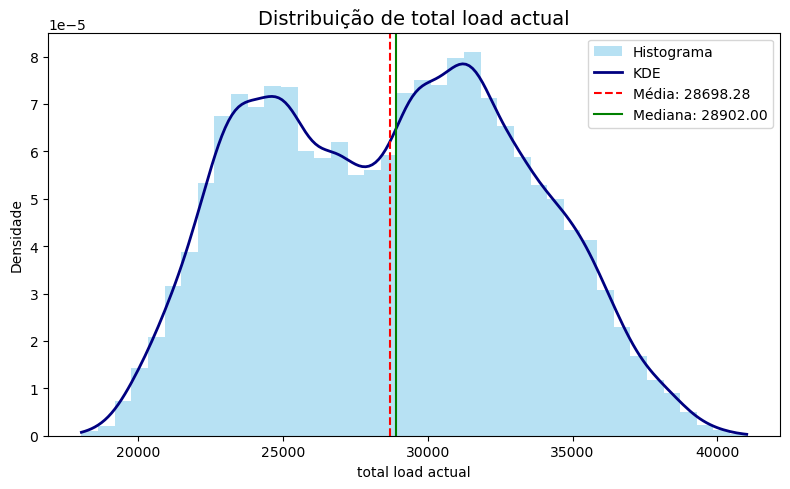

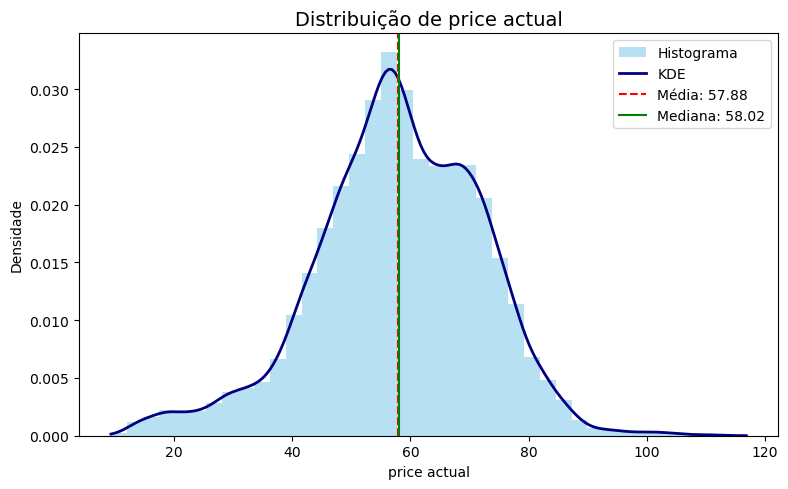

In [40]:
#import numpy as np
#import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

folder = 'figuras'
if not os.path.exists(folder):
    os.makedirs(folder)

# Lista com as colunas que quero analisar
cols_plot = ['total load actual', 'price actual']

for col in cols_plot:
    # Remove valores nulos para o cálculo
    data = df_energia[col].dropna()

    plt.figure(figsize=(8,5))

    #histograma
    plt.hist(data, bins=40, density=True, alpha=0.6, color='skyblue', label='Histograma')

    # Curva KDE
    # Calculamos a densidade de probabilidade suave
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 200)
    plt.plot(x_vals, kde(x_vals), color='navy', lw=2, label='KDE')

    #Linha da Média (rotulo com o valor calculado)
    plt.axvline(data.mean(), color='red', linestyle='--', label=f'Média: {data.mean():.2f}')

    # Linha da Mediana (rotulo com o valor calculado)
    plt.axvline(data.median(), color='green', linestyle='-', label=f'Mediana: {data.median():.2f}')

    # Títulos
    plt.title(f'Distribuição de {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Densidade')

    plt.legend(loc='upper right') # O comando plt.legend() reune todos os 'labels' definidos acima


    plt.tight_layout()#não deixa sobreporem os dados visualmente no gráfico

    # Gerando o nome do arquivo para salvamento
    filename = f"3.1_{col.replace(' ', '_')}_distribuicao.svg"
    filepath = os.path.join(folder, filename)

    # Salvando, sempre antes do plt.show()
    plt.savefig(filepath, format='svg')
    
    plt.show()

<div style="color: green;">

#### Análise do gráfico:
- A distribuição da carga total apresenta comportamento bimodal, indicando a existência de dois regimes distintos de consumo ao longo do tempo. Já o preço da energia apresenta distribuição assimétrica à direita, com concentração em valores médios e ocorrência de picos elevados.A proximidade entre média e mediana na carga indica baixa assimetria, enquanto no preço observa-se uma maior variabilidade. Esses resultados sugerem que o preço da energia é influenciado por múltiplos fatores e apresenta maior instabilidade em comparação à carga.

<div style="color: green;">

## 3.2 Boxplot dados de clima

<div style="color: green;">


#### O que o Boxplot revela (Leitura Técnica)
Cada "caixa" no gráfico representa a distribuição das temperaturas ao longo dos 4 anos:

Linha Central na Caixa: É a Mediana. Se estiver no meio da caixa, a distribuição é simétrica. Se estiver mais para baixo, indica que a cidade passa mais tempo com temperaturas baixas.

Limites da Caixa (Topo e Fundo): Representam os quartis (25% e 75%). A altura da caixa mostra a Variabilidade Interquartílica (onde estão 50% dos dados).

Pontos fora dos "bigodes" (Outliers): São os pontos pretos individuais. Eles representam temperaturas extremas (ondas de calor ou de frio) que fogem do padrão histórico daquela cidade.

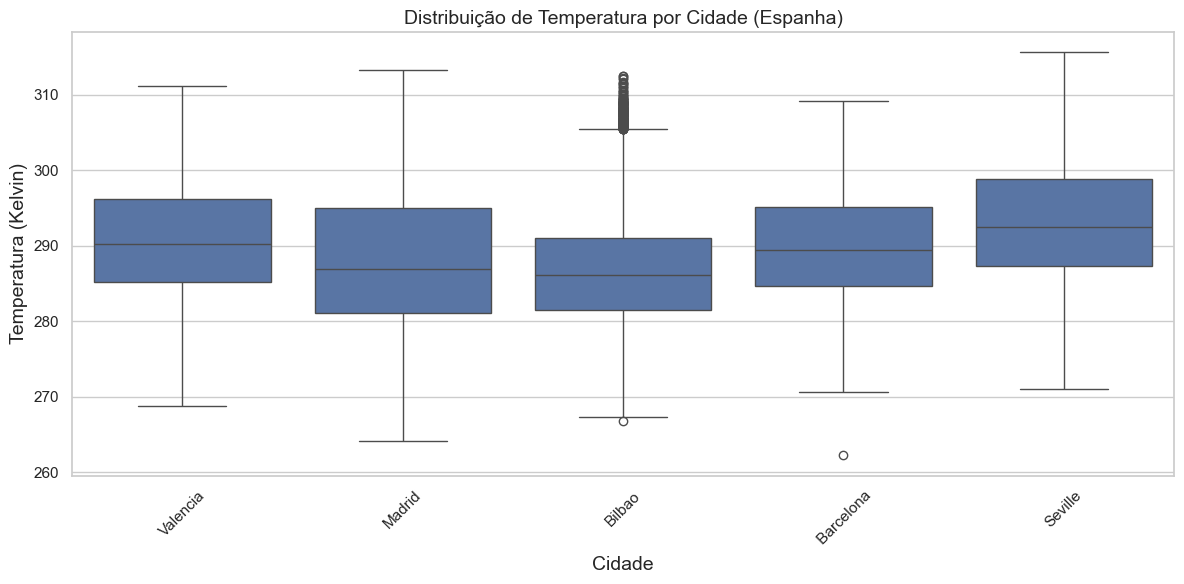

In [41]:

#import matplotlib.pyplot as plt
#import seaborn as sns

# Ajuste de estilo
try:
    sns.set_theme(style="whitegrid")
except AttributeError:
    sns.set(style="whitegrid")

# Define o tamanho da figura
plt.figure(figsize=(12, 6))

# Criando o boxplot:
#Finalidade: Comparar a tendência central (mediana) e a dispersão (quartis) entre cidades.
# O boxplot é essencial para identificar visualmente a variabilidade climática regional.
sns.boxplot(x='city_name', y='temp', data=df_clima)

# Personalização
plt.title('Distribuição de Temperatura por Cidade (Espanha)', fontsize=14)
plt.xlabel('Cidade', fontsize=14)
plt.ylabel('Temperatura (Kelvin)', fontsize=14)

# Rotaciona os rótulos do eixo X em 45 graus para evitar sobreposição dos nomes das cidades
plt.xticks(rotation=45)
# Ajusta automaticamente os elementos para que não fiquem cortados na exportação
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"3.2_boxplot_distr_temp.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

# Exibição dop gráfico
plt.show()

<div style="color: green;">

#### Análise do gráfico:
- Cidades no interior (como Madrid) costumam ter "caixas" e "bigodes" mais compridos, indicando verões muito quentes e invernos muito frios. Cidades costeiras (como Barcelona ou Valência) tendem a ter caixas mais compactas devido ao efeito amenizador do mar.Uma cidade com uma caixa muito grande e muitos outliers (pontos isolados) é mais difícil de prever meteorologicamente.

<div style="color: green;">

## 3.3 Análise de Probabilidade e Dependência

In [42]:
# Definição dos eventos

# Evento A: alta demanda
alta_demanda = df_energia['total load actual'] > df_energia['total load actual'].quantile(0.75)# Seleciona os valores de carga acima do percentil 75 (top 25%)


# Evento B: preço alto
preco_alto = df_energia['price actual'] > df_energia['price actual'].quantile(0.75)# Seleciona os valores de preço acima do percentil 75

# Cálculo das probabilidades

# P(A): Probabilidade de ocorrer alta demanda
# Como True = 1 e False = 0, a média representa a proporção
P_A = alta_demanda.mean()

# P(B): Probabilidade de ocorrer preço alto
P_B = preco_alto.mean()

# P(B|A): Probabilidade de preço alto dado que há alta demanda
P_B_dado_A = preco_alto[alta_demanda].mean()# Filtra apenas os casos onde há alta demanda e calcula a proporção de preços altos

# exibição dos resultados
print(f"(Frequência de alta demanda): {P_A:.3f}")
print(f"(frequência de preço alto): {P_B:.3f}")
print(f"(Probabilidade de preço alto dado que há alta demanda): {P_B_dado_A:.3f}")

(Frequência de alta demanda): 0.250
(frequência de preço alto): 0.250
(Probabilidade de preço alto dado que há alta demanda): 0.457


<div style="color: green;">
#### Análise Estatística

- Probabilidade de preço alto com alta demanda > frequência de preço alto → alta demanda aumenta a chance de preço alto
- Probabilidade de preço alto com alta demanda ≈ frequência de preço alto → pouca relação
- Probabilidade de preço alto com alta demanda < frequência de preço alto → relação inversa

Como vemos que a probabilidade de preço alto dado que há alta demanda é maior que a frequência de preço alto, existe uma correlação entre esses dois eventos. O que acontece nesse caso é a aplicação da probabilidade condicional, ou seja "Qual a chance do preço ser alto sabendo que a demanda está alta?". Esse comportamento é consistente com a lógica de mercado.

<div style="color: green;">
Independência (verificação simples)

In [43]:
# Calculando a Probabilidade Conjunta (P(A ∩ B))
# Verificamos onde ambas as condições são verdadeiras simultaneamente
P_intersec = (alta_demanda & preco_alto).mean() # O método .mean() em uma série de booleanos retorna a proporção de 'True' (0 a 1)

# Exibição dos resultados para comparação
print(f"Probabilidade Observada P(A ∩ B): {P_intersec:.3f}")
print(f"Probabilidade Teórica (Independência) P(A)*P(B): {(P_A * P_B):.3f}")

# Lógica de Verificação de Independência
if abs(P_intersec - (P_A * P_B)) < 0.01:# Se os valores forem muito próximos, os eventos não possuem influência mútua

    print("Conclusão: Os eventos são estatisticamente independentes.")
else:
    print("Conclusão: Existe uma dependência (correlação) entre os eventos.")

Probabilidade Observada P(A ∩ B): 0.114
Probabilidade Teórica (Independência) P(A)*P(B): 0.062
Conclusão: Existe uma dependência (correlação) entre os eventos.


<div style="color: green;">

## 3.4 Heatmap de correlação de Pearson

<div style="color: green;">

#### Análise de Dependência:
A utilização do Mapa de Calor (Heatmap) baseado no coeficiente de correlação de Pearson permite identificar matematicamente como as variáveis do sistema elétrico e climático interagem entre si. O mapa traduz a força da relação linear entre duas variáveis em um valor que varia de -1 a +1:
####  Correlação Próxima de +1:
Indica uma relação direta forte. 
#### Próxima de -1:
Indica uma relação inversa. Se uma variável aumenta, a outra diminui proporcionalmente.
#### Correlação Próxima de 0: 
Indica que não há relação linear entre as variáveis.

<div style="color: green;">

## 3.4.1 Correlação dados de energia

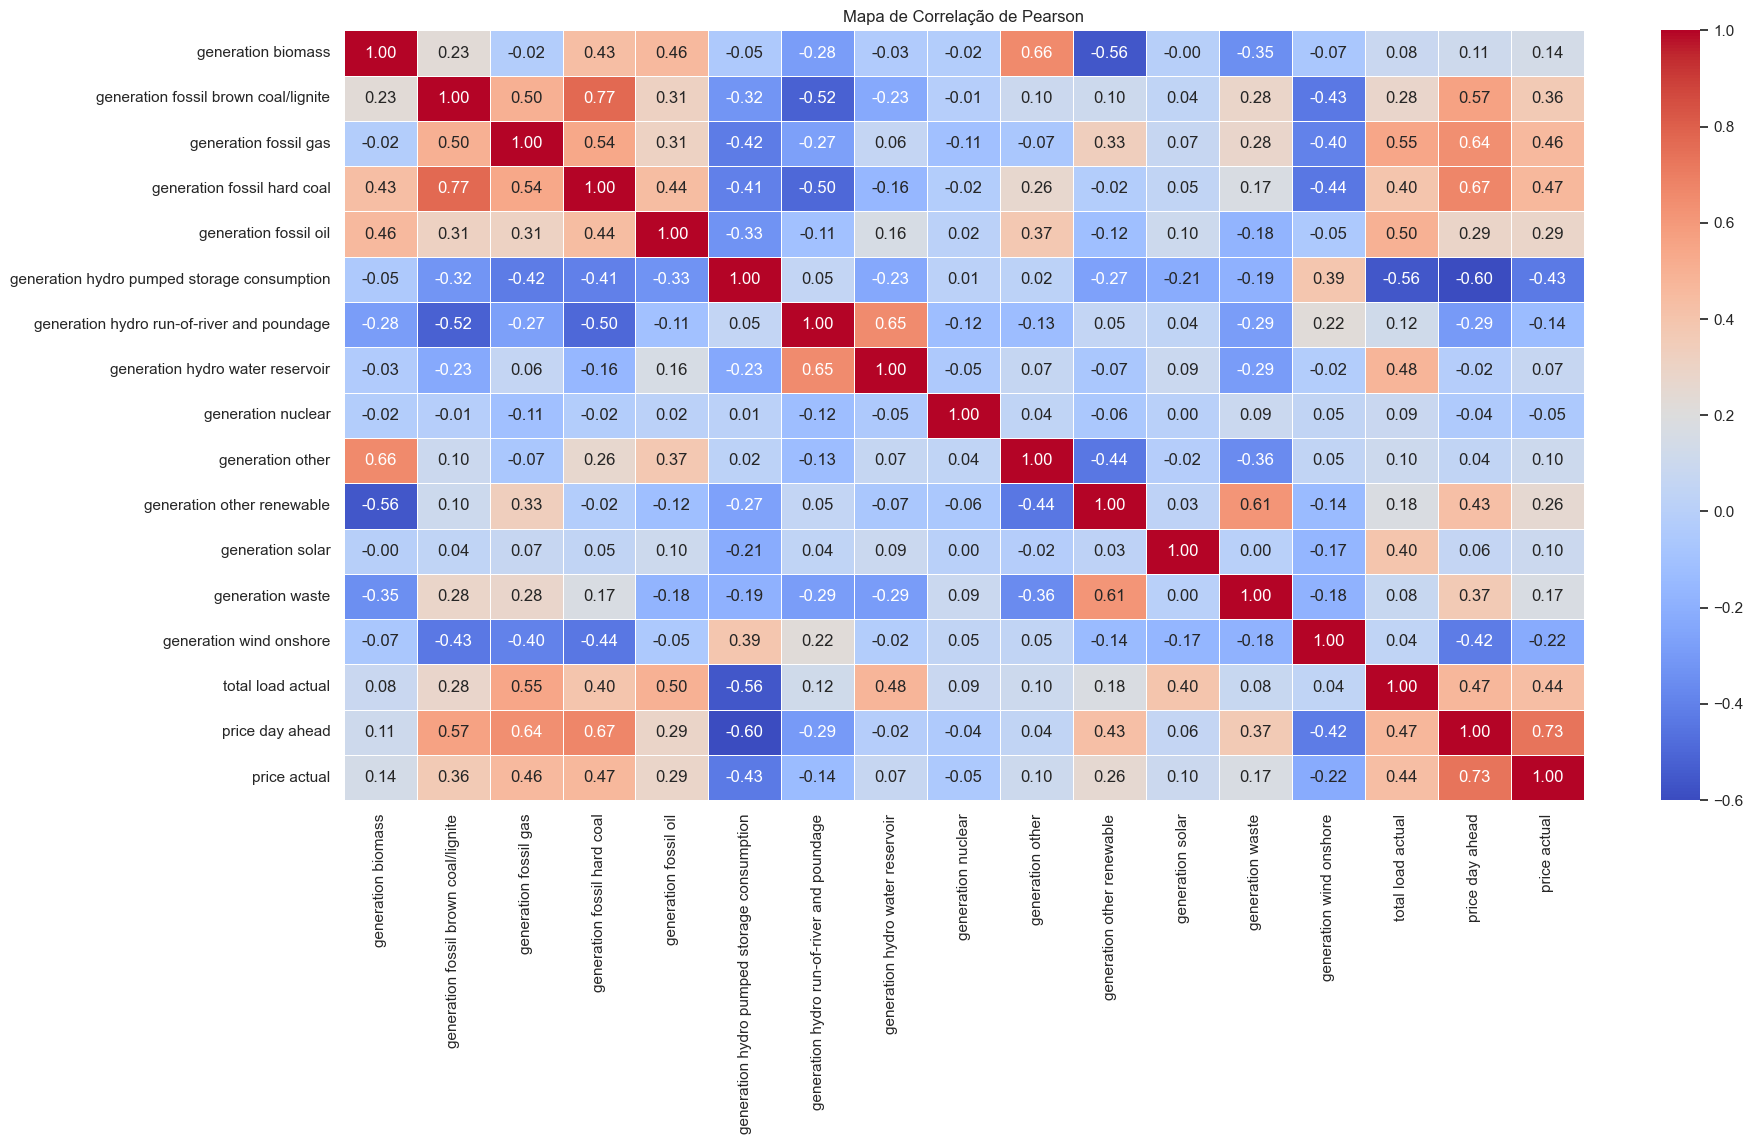

In [44]:

#import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns

# Seleciona as colunas numéricas
num_cols = df_energia.select_dtypes(include=['number'])




# Remove colunas sem variação (onde todos os valores são iguais)
num_cols = num_cols.loc[:, num_cols.nunique() > 1]

# Calcula a correlação de Pearson
corr = num_cols.corr()

# Remove eventuais nulos
corr = corr.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Configuração do Gráfico
plt.figure(figsize=(20, 10))

sns.heatmap(corr, 
            cmap='coolwarm', 
            annot=True, 
            fmt=".2f", 
            linewidths=.5, 
            linecolor='white')

plt.title("Mapa de Correlação de Pearson")

# Gerando o nome do arquivo para salvamento
filename = f"3.4.1_correlacao_pearson.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: green;">

#### Análise do gráfico
- É possível observar a correlação entre as fontes fósseis, gás fóssil(fossil gas) e carvão(coal), valores de 0,54 e 0,77, essas fontes são usadas juntas para atender picos demanda. Observa-se também forte correlação entre preço previsto(price day ahead) e preço atual(price actual), indicando boa capacidade predicativa. Fontes renováveis, como eólica(wind onshore), apresentam correlação negativa com o preço, sugerindo que o aumento da oferta reduz o custo da energia. Já a energia nuclear apresenta baixíssima correlação e até mesmo correlação negativa com outras fontes, caracterizando sua operação constante.

<div style="color: green;">

## 3.4.2 Correlação em dados de clima

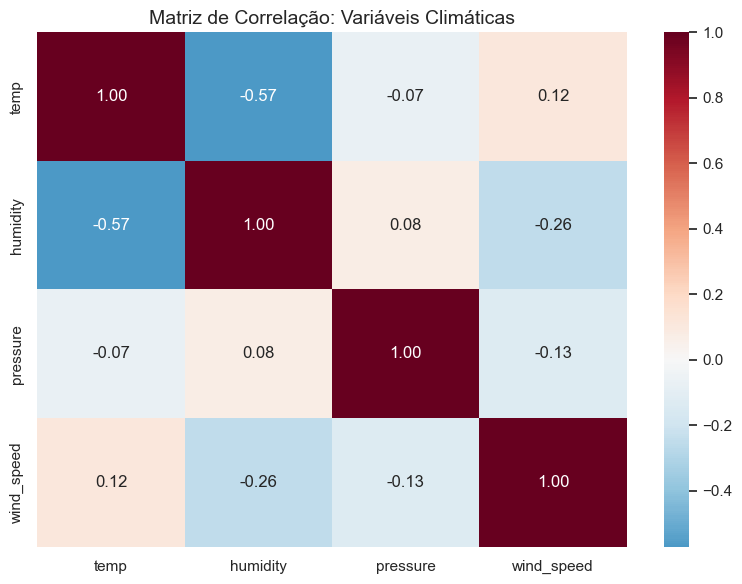

In [45]:
#import matplotlib.pyplot as plt
#import seaborn as sns

# Finalidade: Identificar a força e a direção da relação entre as variáveis
#climáticas

# Seleção de Atributos Numéricos:
# Filtra apenas as colunas quantitativas para evitar erros de tipo (TypeError)
# ao calcular o coeficiente de correlação de Pearson.
cols_analise = ['temp', 'humidity', 'pressure', 'wind_speed']
df_corr = df_clima[cols_analise].corr()

#Configuração Visual do Mapa de Calor
plt.figure(figsize=(8, 6))

# Parâmetros Técnicos do mapa de calor
# annot=True: exibe os valores numéricos dos coeficientes dentro das células
# cmap='RdBu_r': paleta divergente (Vermelho para Positivo, Azul para Negativo)
# center=0: define o branco como o ponto neutro (ausência de correlação).
# fmt=".2f": formata os números para duas casas decimais.
sns.heatmap(df_corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f")

# Finalização e título
plt.title('Matriz de Correlação: Variáveis Climáticas', fontsize=14)
plt.tight_layout() # Garante que as legendas e eixos não sejam cortados

# Gerando o nome do arquivo para salvamento
filename = f"3.4.2_correlacao_clima.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

# Exibição do gráfico
plt.show()


<div style="color: green;">

#### Análise do gráfico:
- É possível observar que a correlação mais forte é entre a temperatura e a umidade, ela é uma correlação negativa, o que significa que quando a temperatura sobe a umidade tende a descer.É posivel observar que não existe nenhuma outra correlação mais forte entre as outras variáveis.

<div style="color: green;">

## 3.5 Série temporal

<div style="color: green;">

#### Análise de Séries Temporais: Evolução Histórica do Preço
A análise da evolução do preço da energia ao longo do tempo é o ponto de partida para compreender a dinâmica do mercado elétrico. A utilização de um gráfico de linhas temporal justifica-se pelos seguintes aspetos técnicos:

#### Identificação de Tendências e Ciclicidade
Diferente de uma tabela estática, o gráfico de séries temporais permite observar visualmente se o preço da energia está em uma trajetória de subida ou descida a longo prazo. No contexto do mercado espanhol, este gráfico revela a sazonalidade: padrões que se repetem anualmente (ex: preços mais altos no inverno ou verão devido à climatização) ou semanalmente.

#### Deteção de Choques e Anomalias
O gráfico de linhas é a melhor ferramenta para identificar picos de volatilidade. Momentos de crise energética, falhas no fornecimento ou eventos geopolíticos aparecem como "agulhas" no gráfico.

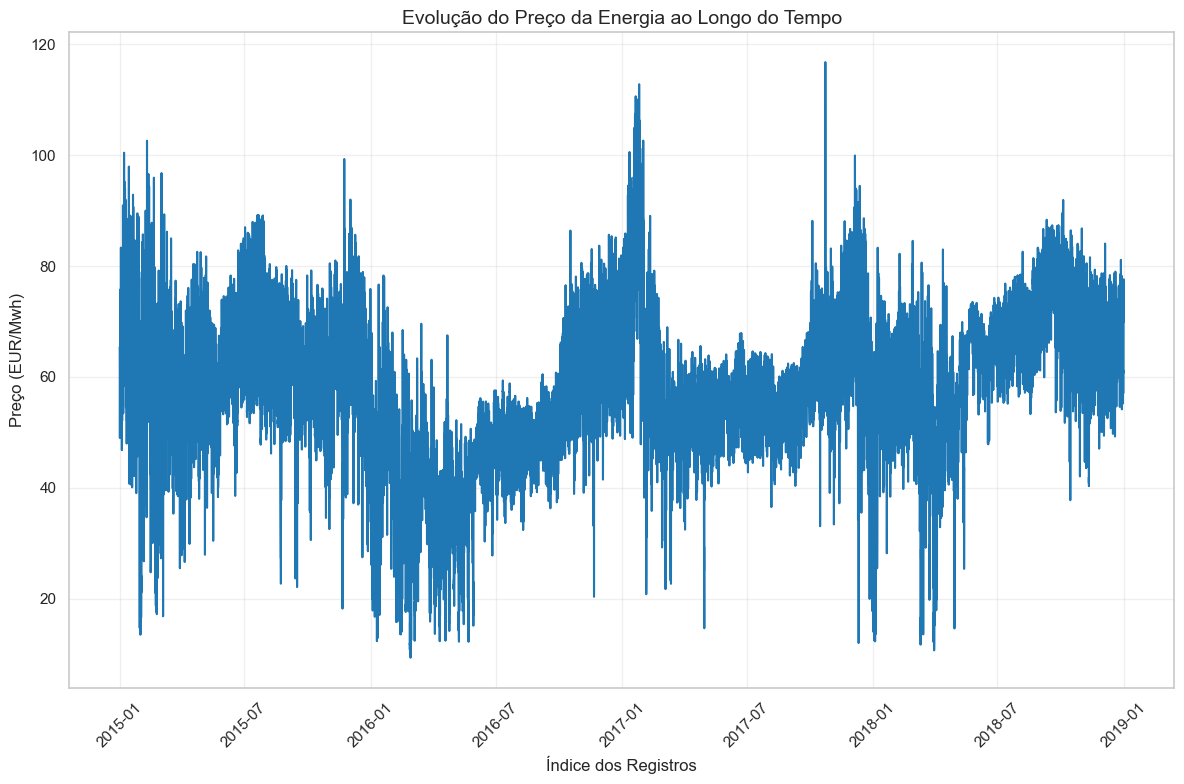

In [46]:
#import pandas as pd
#import matplotlib.pyplot as plt
#identificação automática da coluna temporal
col_tempo = None
for col in df_energia.columns:
# Verifica se 'time' ou 'date' está no nome da coluna, independente de maiúsculas
    if 'time' in col.lower() or 'date' in col.lower():
        col_tempo = col
        break

# Configuração do tamnho do gráfico
plt.figure(figsize=(12, 8))

#Lógica de Plotagem (Se encontrou data vs. Se não encontrou)

if col_tempo:
    #Converte a coluna para o formato datetime
    df_energia[col_tempo] = pd.to_datetime(df_energia[col_tempo])

    # Plota os dados, eixo X = tempo, Eixo Y = preço atual

    plt.plot(df_energia[col_tempo], df_energia['price actual'], color='tab:blue', linewidth=1)
    plt.xlabel('Data e Hora')
else:
    # Plano B: Usa o índice numérico se nenhuma coluna de tempo for detectada
    plt.plot(df_energia.index, df_energia['price actual'], color='tab:blue')
    plt.xlabel('Índice dos Registros')

# Rótulos do gráfico
plt.title('Evolução do Preço da Energia ao Longo do Tempo', fontsize=14)
plt.ylabel('Preço (EUR/Mwh)')

# Ajustes de legibilidade
plt.xticks(rotation=45) # aotaciona as datas para não sobrepor o texto
plt.grid(True, alpha=0.3) # adiciona uma grade para facilitar a leitura de valores
plt.tight_layout()# ajusta as margens para o gráfico não cortar nas bordas

# Gerando o nome do arquivo para salvamento
filename = f"3.5_evolucao_preco.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

# Mostrar o resultado
plt.show()

<div style="color: green;">

#### Análise do gráfico:
- Ao longo do ano, os valores não são constantes, indicando que o preço da energia varia com o tempo, existem meses com preços mais altos e outros com preços mais baixos. Isso mostra que o mercado de energia é dinâmico e que podem ocorrer influência sazonal (clima), sol, chuva, calor, frio que interferem na geração de energia e no preço da energia. O gráfico permite identificar uma tendência geral de subida ou descida ao longo do tempo, volatilidade e possíveis padrões repetitivos.

<div style="color: green;">

## 3.6 Análise de sazonalidade da temperatura

<div style="color: green;">

#### Análise de Sazonalidade: Ciclos Mensais de Temperatura
A análise da variação sazonal da temperatura através de médias mensais agrupadas por cidade é fundamental para compreender os ciclos de longo prazo que regem o mercado de energia. A utilização desta abordagem justifica-se pelos seguintes pontos:

#### Identificação de Padrões Climáticos Regionais
Ao agrupar os dados por mês e cidade, o gráfico permite visualizar de forma clara as curvas de aquecimento e arrefecimento de cada região da Espanha. Cidades com curvas mais "acentuadas" (como Madrid ou Sevilha) indicam climas continentais com verões e invernos rigorosos, enquanto curvas mais "suaves" indicam climas costeiros. Esta distinção é crucial para o modelo, pois a carga elétrica responde de forma diferente ao clima em cada uma dessas zonas.

#### Correlação com a Demanda Energética
O gráfico justifica a inclusão da variável "Mês" como um preditor no modelo de Machine Learning. Existe uma relação física direta: nos meses onde a curva atinge o pico (julho/agosto) ou o vale (janeiro/fevereiro), a carga total do sistema elétrico tende a aumentar devido ao uso intensivo de ar condicionado e sistemas de aquecimento, respetivamente

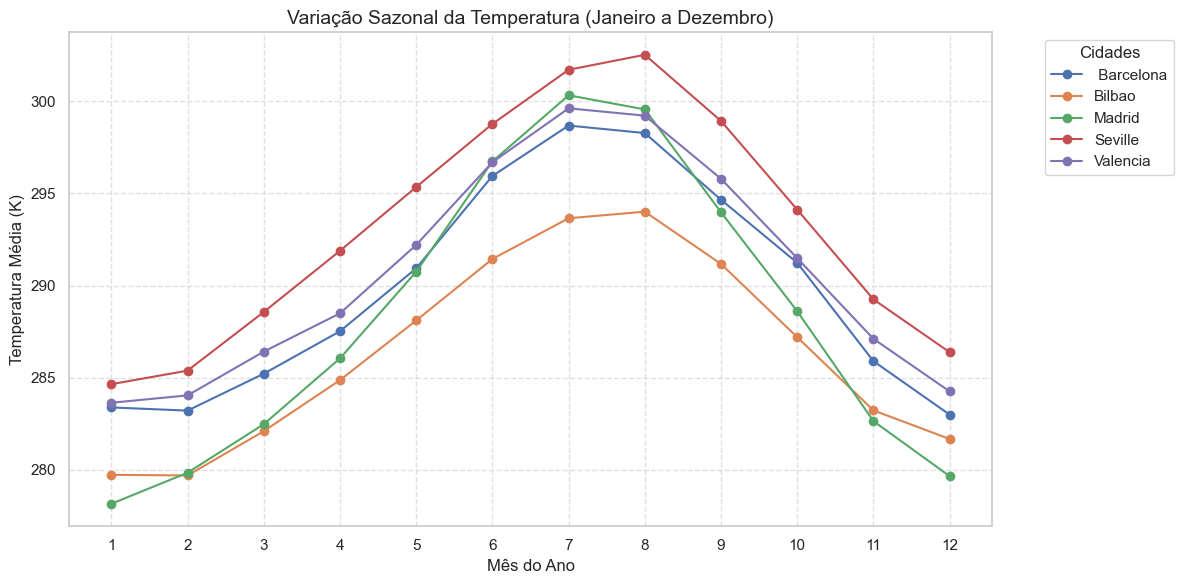

In [47]:

#import matplotlib.pyplot as plt

# Criar a coluna 'mes' a partir do índice ou da coluna de tempo
# Se o seu índice for do tipo datetime:
df_clima['mes'] = df_clima.index.month 

# SE o comando acima der erro, tente este (usando a coluna de data original):
# df_clima['mes'] = pd.to_datetime(df_clima['dt_iso']).dt.month

#Agora sim, fazemos o agrupamento e a pivotação (unstack)
df_sazonal = df_clima.groupby(['mes', 'city_name'])['temp'].mean().unstack()

#Plotagem usando Matplotlib
plt.figure(figsize=(12, 6))

for cidade in df_sazonal.columns:
    plt.plot(df_sazonal.index, df_sazonal[cidade], marker='o', label=cidade)

# Personalização técnica
plt.title('Variação Sazonal da Temperatura (Janeiro a Dezembro)', fontsize=14)
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Temperatura Média (K)', fontsize=12)
plt.xticks(range(1, 13)) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cidades', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"3.6_variacao_sazonal_temp.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: green;">

#### Análise do gráfico:
- É possível observar a variação de temperatura durante os meses do ano, durante o verão na Espanha que ocorre entre o final de junho até setembro vemos temperaturas mais elevadas o que é natural. No inverno que se estende do fim de dezembro até março vemos temperaturas mais baixas que também é o natural. A diferença entre os picos de temperatura também explica por que a carga elétrica na Espanha tem picos de consumo diferentes dependendo da região e da estação do ano. Além da diferença do clima entre cidades costeiras e do interior.

<div style="color: green;">

## 3.7 Geração de energia ao longo de 24 horas

<div style="color: green;">

#### Análise de Perfil Diário: Geração Média Horária
A análise da geração média de energia ao longo das 24 horas do dia é fundamental para entender a dinâmica operacional do setor elétrico espanhol. A utilização deste gráfico justifica-se pelos seguintes aspetos técnicos e analíticos:

#### Identificação do Ciclo de Atividade Humana
O gráfico revela o "ritmo cardíaco" da sociedade. Através dele, é possível observar os períodos de rampa de subida (quando a população acorda e a indústria inicia operações) e os patamares de pico (geralmente no meio do dia e ao início da noite). Esta visualização justifica a importância da variável "hora" como o principal preditor no modelo de previsão de séries temporais.

#### Compreensão do Mix Energético e Disponibilidade
Ao agregar todas as fontes na geracao_total, o gráfico permite analisar se o sistema elétrico possui uma base de geração estável ou se depende de fontes que variam conforme o horário. Por exemplo, a presença de picos durante o dia pode estar fortemente correlacionada com a geração solar, enquanto a manutenção da geração durante a madrugada revela o papel das energias nuclear e eólica (carga de base).

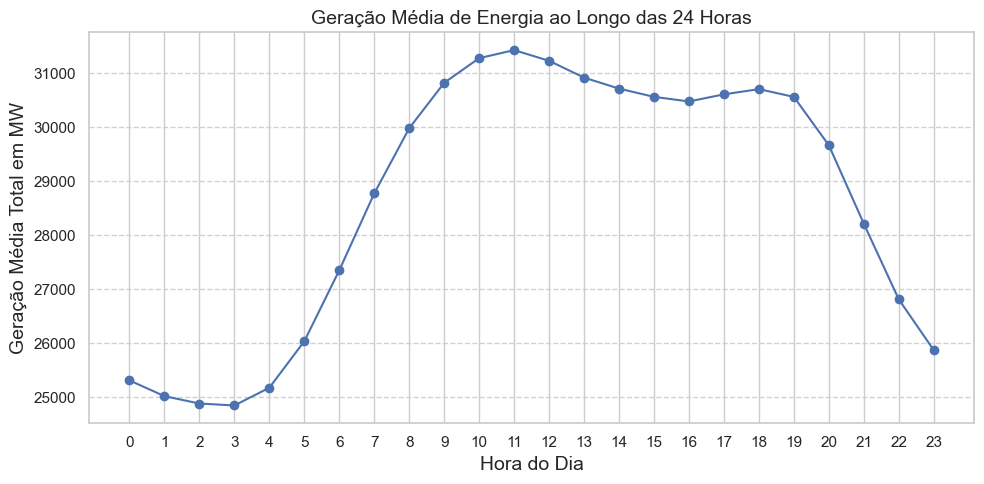

In [48]:
#import pandas as pd
#import matplotlib.pyplot as plt


#garante coluna de tempo correta

col_tempo = None
for col in df_energia.columns:
    if 'time' in col.lower() or 'date' in col.lower():
        col_tempo = col
        break
# Converte a coluna de tempo para formato datetime e define como índice
if col_tempo:
    df_energia[col_tempo] = pd.to_datetime(df_energia[col_tempo])
    df_energia = df_energia.set_index(col_tempo)
else:
        # Caso não exista coluna de tempo, usa o índice atual
    df_energia.index = pd.to_datetime(df_energia.index)

# Criar coluna de hora(0 a 23)

df_energia['hora'] = df_energia.index.hour

#Selecionar corretamente colunas de geração
colunas_geracao = [col for col in df_energia.columns if 'generation' in col.lower()]

# Soma todas as fontes de geração para obter a geração total
df_energia['geracao_total'] = df_energia[colunas_geracao].sum(axis=1)
# Agrupa os dados por hora e calcula a média da geração total
geracao_hora = df_energia.groupby('hora')['geracao_total'].mean()

# Garante todas as horas
geracao_hora = geracao_hora.reindex(range(24))

#Plot do gráfico
plt.figure(figsize=(10,5))
plt.plot(geracao_hora.index, geracao_hora.values, marker='o')
plt.title('Geração Média de Energia ao Longo das 24 Horas', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=14)
plt.ylabel('Geração Média Total em MW', fontsize=14)
# Ajustes visuais
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.9)# Grade apenas horizontal para facilitar leitura de valores
# Ajusta layout e exibe o gráfico
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"3.7_geracao_media_24h.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: green;">

#### Análise do gráfico:
- É possível observar pelo gráfico que durante o período da noite quando as pessoas tendem a dormir ocorre a redução da demanda e ocorre também uma menor geração. No período da manhã até a tarde ocorre um pico de demanda/geração o que é natural, considerando que as pessoas estão no trabalho e realizando suas atividades cotidianas que inclui muitas vezes equipamentos que consomem energia elétrica.

<div style="color: blue;">

# 4. Visualizações Interpretadas (Seção 4.7)

<div style="color: blue;">
    
## 4.0 - Importação de Dados

In [49]:
# ==========================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st


# ==========================================
# 2. CONFIGURAÇÕES INICIAIS
# ==========================================
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


# ==========================================
# 3. CARREGAMENTO DOS DADOS
# ==========================================
df_energia_4 = df_energia.copy()
df_clima_4 = df_clima.copy()


# ==========================================
# 4. VISUALIZAÇÃO INICIAL
# ==========================================
print("Dimensão do dataset de energia:", df_energia_4.shape)
print("Dimensão do dataset climático:", df_clima_4.shape)

display(df_energia_4.head())
display(df_clima_4.head())

Dimensão do dataset de energia: (35064, 19)
Dimensão do dataset climático: (175320, 14)


,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price day ahead,price actual,hora,geracao_total
time,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,50.10,65.41,23,28251.0
2015-01-01 00:00:00+00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,48.10,64.92,0,27818.0
2015-01-01 01:00:00+00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,47.33,64.48,1,26796.0
2015-01-01 02:00:00+00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,21286.0,42.27,59.32,2,25223.0
2015-01-01 03:00:00+00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,20264.0,38.41,56.04,3,24620.0


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,mes
time,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,12
2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001.0,77.0,1.0,62.0,0.0,0.0,0.0,0.0,1
2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,1
2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,1
2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002.0,78.0,0.0,23.0,0.0,0.0,0.0,0.0,1


<div style="color: blue;">
    
## 4.1 - Série Temporal - Line Plot

<div style="color: blue;">
    
Observa-se que a carga total de energia apresenta um padrão semanal bastante claro ao longo de janeiro de 2015. Nos dias úteis, a demanda é consistentemente mais elevada, com picos frequentes entre 35 mil e 40 mil unidades de carga. Já nos fins de semana, a carga permanece em níveis menores, geralmente entre 22 mil e 34 mil.

Esse comportamento sugere que a atividade econômica e industrial influencia fortemente o consumo energético, aumentando a demanda durante a semana e reduzindo-a aos sábados e domingos. Além disso, nota-se uma oscilação diária recorrente, com quedas durante a madrugada e aumento ao longo do dia, especialmente nos dias úteis.

O maior pico do período ocorre em torno da terceira semana de janeiro, quando a carga nos dias úteis ultrapassa 40 mil, enquanto os fins de semana não atingem esse mesmo patamar. Isso reforça a existência de sazonalidade semanal na demanda de energia.

In [50]:
print(df_energia_4.columns)

Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore', 'total load actual',
       'price day ahead', 'price actual', 'hora', 'geracao_total'],
      dtype='object')


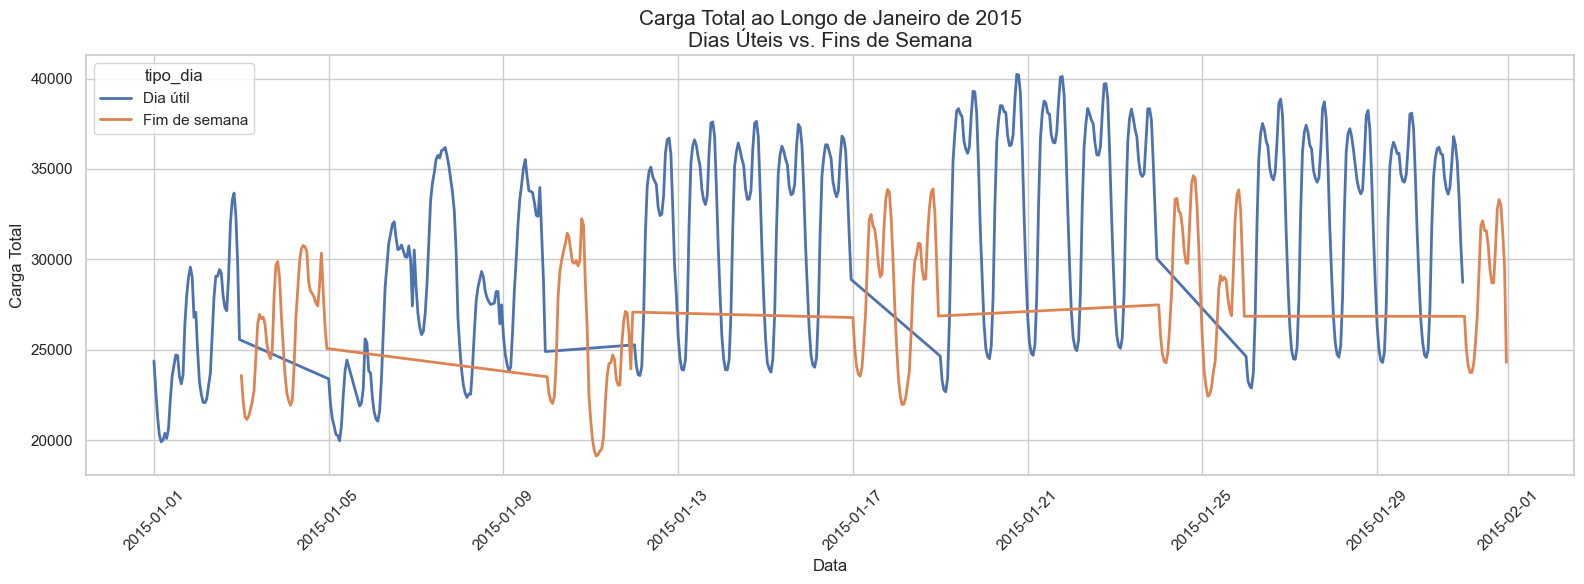

In [51]:
# LINE PLOT - CARGA TOTAL EM 1 MÊS

# Ajustando a coluna de data
# Trazendo o índice de volta para uma coluna chamada 'time'
df_energia_4 = df_energia_4.reset_index()
df_clima_4 = df_clima_4.reset_index()

# AGORA SIM o seu código vai encontrar a coluna:
df_energia_4['time'] = pd.to_datetime(df_energia_4['time'], utc=True).dt.tz_localize(None)

# Filtrando janeiro de 2015
df_mes = df_energia_4[
    (df_energia_4["time"] >= "2015-01-01") &
    (df_energia_4["time"] < "2015-02-01")
].copy()

# Classificando os dias
df_mes["tipo_dia"] = df_mes["time"].dt.weekday.map(
    lambda x: "Fim de semana" if x >= 5 else "Dia útil"
)

# Estilo do gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=df_mes,
    x="time",
    y="total load actual",
    hue="tipo_dia",
    linewidth=2
)

plt.title(
    "Carga Total ao Longo de Janeiro de 2015\nDias Úteis vs. Fins de Semana",
    fontsize=15
)
plt.xlabel("Data")
plt.ylabel("Carga Total")
plt.xticks(rotation=45)
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.1_carga_uteis_fds.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: blue;">
    
## 4.2 - Correlação Entre Variáveis Climaticas - Heatmap

<div style="color: blue;">
    
Observa-se que as fontes de geração renovável são as mais influenciadas pelas condições climáticas. A geração solar apresenta correlação positiva moderada com a temperatura (0,42), indicando que dias mais quentes tendem a coincidir com maior produção solar. Por outro lado, a umidade possui forte correlação negativa com a geração solar (-0,58), sugerindo que condições mais úmidas reduzem significativamente sua produção, possivelmente devido à maior presença de nuvens e menor incidência de radiação solar.

A geração eólica apresenta correlação positiva com a velocidade do vento (0,32), como esperado, já que ventos mais intensos aumentam a produção de energia eólica. Também há uma leve relação positiva entre nebulosidade e geração eólica (0,12), o que pode indicar que condições climáticas mais instáveis favorecem ventos mais fortes.

As fontes fósseis, nucleares e parte da geração hidrelétrica apresentam correlações muito próximas de zero com as variáveis climáticas. Isso indica que essas formas de geração são relativamente independentes das condições meteorológicas e costumam operar de maneira mais constante ao longo do tempo.

Entre todas as relações observadas, a mais forte do gráfico é a correlação negativa entre umidade e geração solar, reforçando que a produção de energia solar é a mais sensível às variações do clima.

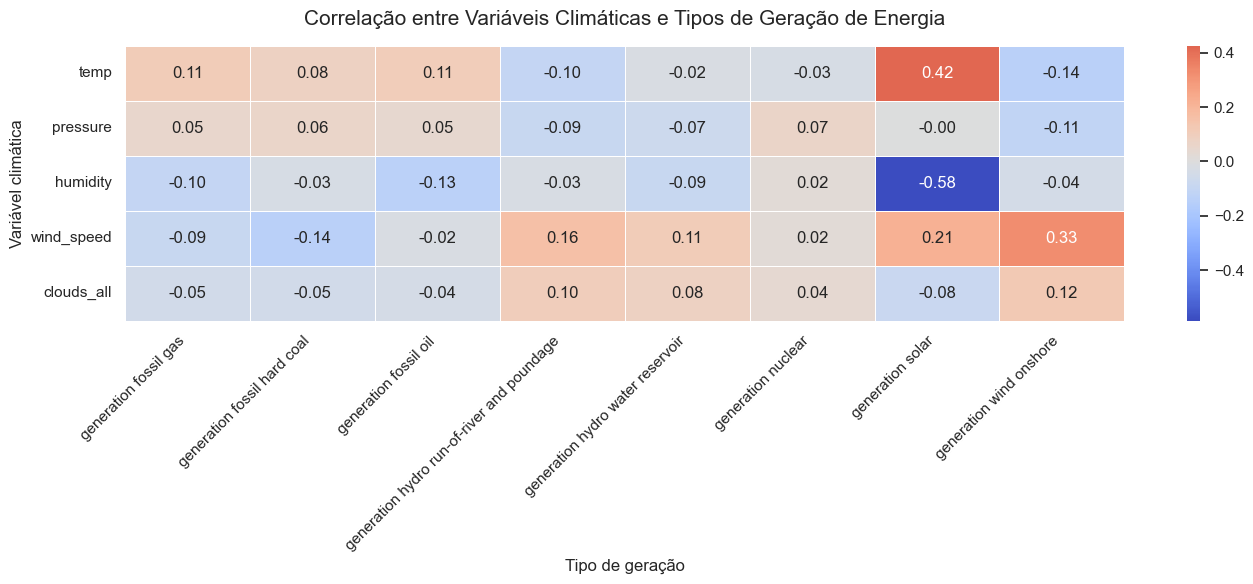

In [52]:
# HEATMAP DE CORRELAÇÃO
# Relação entre variáveis climáticas e tipos de geração
# Ajustando as colunas de data

df_energia_4["time"] = pd.to_datetime(df_energia_4["time"], utc=True).dt.tz_convert(None)
df_clima_4["dt_iso"] = pd.to_datetime(df_clima_4["dt_iso"], utc=True).dt.tz_convert(None)

# Selecionando apenas as colunas climáticas numéricas

colunas_clima = [
    "temp",
    "pressure",
    "humidity",
    "wind_speed",
    "clouds_all"
]

# Como existem várias cidades no df_clima_4,
# vamos tirar a média por horário
df_clima_4_media = (
    df_clima_4
    .groupby("dt_iso")[colunas_clima]
    .mean()
    .reset_index()
)

# Selecionando os tipos de geração de energia

colunas_energia = [
    "generation fossil gas",
    "generation fossil hard coal",
    "generation fossil oil",
    "generation hydro run-of-river and poundage",
    "generation hydro water reservoir",
    "generation nuclear",
    "generation solar",
    "generation wind onshore"
]

# Mantendo apenas data + colunas desejadas
df_energia_4_corr = df_energia_4[["time"] + colunas_energia].copy()


# Juntando clima e energia pela data/hora

df_merge = pd.merge(
    df_energia_4_corr,
    df_clima_4_media,
    left_on="time",
    right_on="dt_iso",
    how="inner"
)

# Removendo a coluna duplicada de data
df_merge.drop(columns="dt_iso", inplace=True)

# Calculando a matriz de correlação

corr = df_merge[colunas_energia + colunas_clima].corr()

# Queremos apenas:
# linhas = variáveis climáticas
# colunas = tipos de geração
corr_filtrada = corr.loc[colunas_clima, colunas_energia]


# Plotando o heatmap

plt.figure(figsize=(14, 6))

sns.heatmap(
    corr_filtrada,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlação entre Variáveis Climáticas e Tipos de Geração de Energia",
    fontsize=15,
    pad=15
)

plt.xlabel("Tipo de geração")
plt.ylabel("Variável climática")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.2_correlacao_clima_geracao.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: blue;">
    
## 4.3 - Demanda de Energia por Hora - Boxplot

<div style="color: blue;">
    
bserva-se que a demanda de energia varia significativamente ao longo do dia. Durante a madrugada, entre 0h e 5h, a carga total permanece nos níveis mais baixos, com medianas próximas de 22 mil a 25 mil, refletindo o menor consumo residencial e industrial nesse período.

A partir das 6h, a demanda começa a crescer rapidamente, acompanhando o início das atividades econômicas e o aumento do consumo nas residências. Entre 8h e 12h, a carga já atinge patamares elevados, com medianas acima de 30 mil.

O pico de demanda ocorre no final da tarde e início da noite, principalmente entre 18h e 20h, quando a mediana ultrapassa 32 mil e alguns valores chegam a mais de 40 mil. Esse comportamento é compatível com o horário em que residências, comércio e parte da atividade industrial estão simultaneamente em funcionamento.

Após as 21h, a demanda volta a cair gradualmente, indicando a redução do consumo ao longo da noite. Além disso, nota-se maior dispersão dos valores durante o período diurno e noturno, especialmente entre 7h e 20h, sugerindo que a demanda nesses horários é mais sensível a variações sazonais e ao tipo de dia.

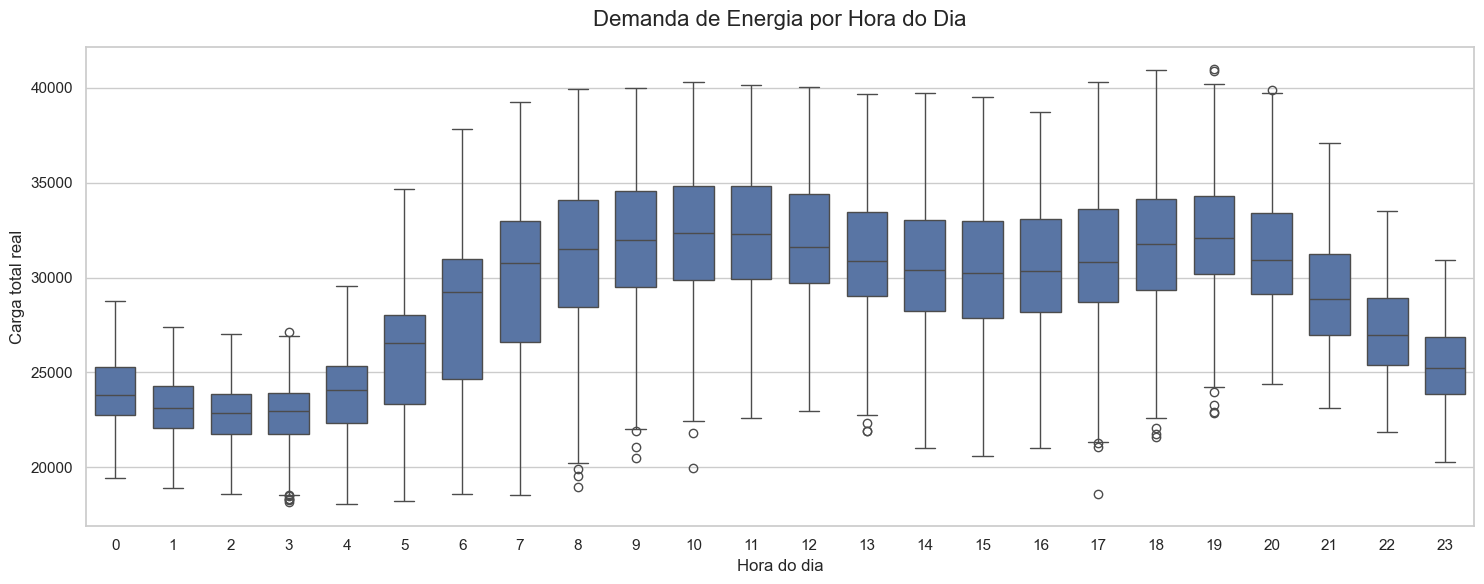

In [53]:
# BOXPLOT - VERSÃO MAIS BONITA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_energia_4["time"] = pd.to_datetime(df_energia_4["time"], utc=True).dt.tz_convert(None)

df_demanda = df_energia_4[["time", "total load actual"]].copy()
df_demanda = df_demanda.dropna(subset=["total load actual"])
df_demanda["hora"] = df_demanda["time"].dt.hour

sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))

sns.boxplot(
    data=df_demanda,
    x="hora",
    y="total load actual",
    width=0.7
)

plt.title("Demanda de Energia por Hora do Dia", fontsize=16, pad=15)
plt.xlabel("Hora do dia", fontsize=12)
plt.ylabel("Carga total real", fontsize=12)
plt.xticks(range(24))
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.3_boxplot_demanda_por_hora.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: blue;">
    
## 4.4 - Temperatura - Regressão

<div style="color: blue;">
    
Observa-se uma relação positiva entre a temperatura em Madrid e a carga total de energia, indicada pela inclinação crescente da reta de regressão. Em média, temperaturas mais elevadas tendem a estar associadas a uma demanda maior de energia.

Entretanto, a dispersão dos pontos é bastante elevada, o que mostra que a temperatura, sozinha, não explica completamente a variação da carga elétrica. Para uma mesma faixa de temperatura, existem valores de demanda bastante diferentes, indicando que outros fatores — como horário do dia, estação do ano, dia útil ou fim de semana — também influenciam fortemente o consumo.

A tendência de aumento da carga em temperaturas mais altas pode estar relacionada ao uso mais intenso de sistemas de refrigeração e ar-condicionado durante períodos mais quentes. Ainda assim, a inclinação suave da reta sugere que essa influência é moderada, e não tão forte quanto em regiões com climas extremamente quentes.

Também é possível notar que os maiores valores de carga tendem a se concentrar nas temperaturas mais elevadas, acima de aproximadamente 300 K, reforçando a associação entre calor e aumento da demanda energética.

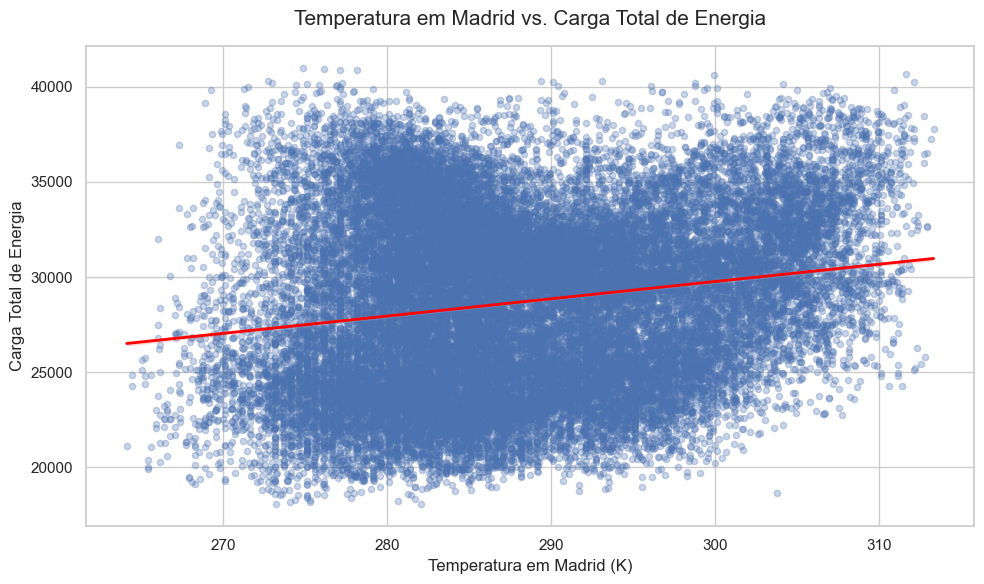

Correlação entre temperatura e carga total: 0.185


In [54]:
# Temperatura de Madrid vs. Carga Total COM PROGRESSÃO

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Ajustando colunas de data

df_energia_4["time"] = pd.to_datetime(
    df_energia_4["time"],
    utc=True
).dt.tz_convert(None)

df_clima_4["dt_iso"] = pd.to_datetime(
    df_clima_4["dt_iso"],
    utc=True
).dt.tz_convert(None)


# Filtrando apenas os dados de Madri

df_madrid = df_clima_4[
    df_clima_4["city_name"] == "Madrid"
][["dt_iso", "temp"]].copy()

# Selecionando a carga total de energia

df_carga = df_energia_4[
    ["time", "total load actual"]
].copy()

# Removendo valores nulos
df_madrid = df_madrid.dropna(subset=["temp"])
df_carga = df_carga.dropna(subset=["total load actual"])

# Juntando temperatura e carga pela data/hora

df_merge = pd.merge(
    df_madrid,
    df_carga,
    left_on="dt_iso",
    right_on="time",
    how="inner"
)

# Criando o gráfico

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_merge,
    x="temp",
    y="total load actual",
    scatter_kws={
        "alpha": 0.3,
        "s": 20
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

# Ajustando

plt.title(
    "Temperatura em Madrid vs. Carga Total de Energia",
    fontsize=15,
    pad=15
)

plt.xlabel("Temperatura em Madrid (K)")
plt.ylabel("Carga Total de Energia")

plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.4_temperatura_madri_carga_total.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

# Exibindo a correlação numérica

correlacao = df_merge["temp"].corr(df_merge["total load actual"])

print(f"Correlação entre temperatura e carga total: {correlacao:.3f}")

<div style="color: blue;">
    
## 4.5 - Composição da Geração - Area Chart

<div style="color: blue;">
    
Observa-se que a geração fóssil é a principal fonte de energia ao longo de todo o dia, mantendo-se relativamente elevada e estável. Seu nível aumenta principalmente no final da tarde e início da noite, quando a demanda total do sistema também tende a crescer.

A geração eólica é a segunda maior contribuição do gráfico e permanece significativa durante praticamente todas as 24 horas. Diferentemente da solar, ela não depende da presença de luz solar, o que permite uma participação importante inclusive durante a madrugada.

A geração solar aparece apenas entre aproximadamente 7h e 16h, atingindo seu pico próximo das 11h–12h. Após esse horário, sua produção diminui rapidamente até desaparecer no início da noite. Isso é consistente com o ciclo diário de incidência solar.

A geração hidrelétrica apresenta um comportamento intermediário, com aumento perceptível entre o final da tarde e a noite, especialmente após as 17h. Esse padrão sugere que a fonte hídrica é utilizada como complemento para atender ao aumento da demanda quando a geração solar começa a cair.

Nota-se também que, à medida que a produção solar diminui no final do dia, a geração fóssil e hidrelétrica aumentam para compensar essa perda. Isso evidencia a complementaridade entre as diferentes fontes de energia ao longo das 24 horas.

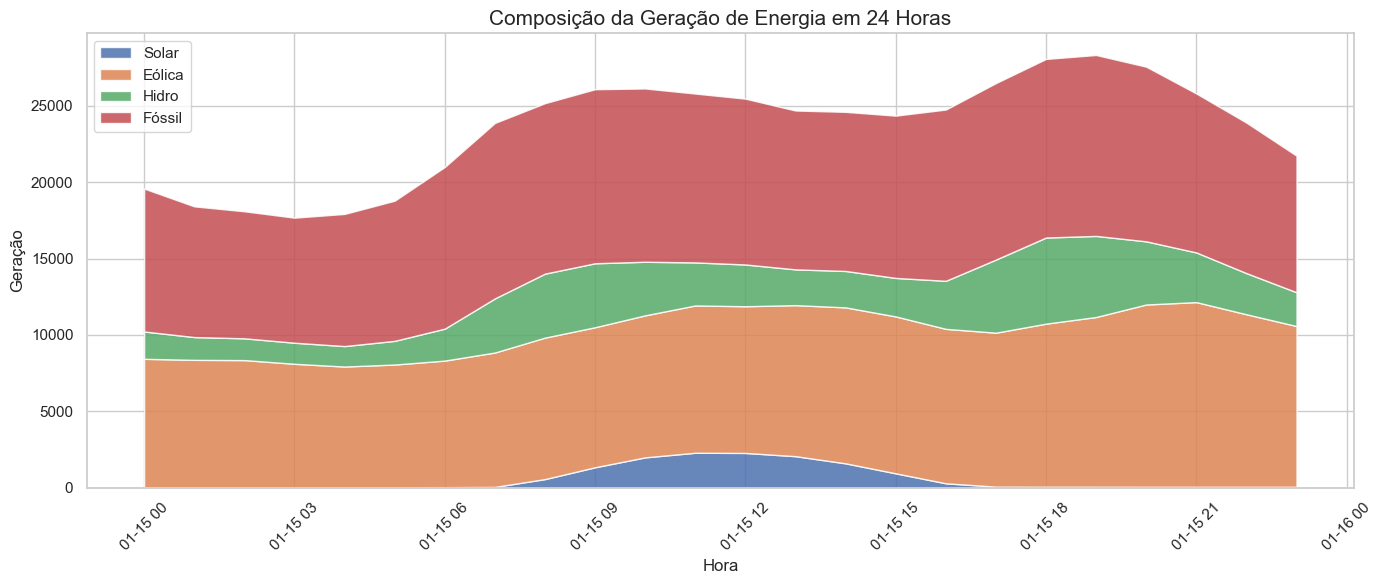

In [55]:
# VERSÃO MAIS ROBUSTA

import pandas as pd
import matplotlib.pyplot as plt

df_energia_4["time"] = pd.to_datetime(df_energia_4["time"], utc=True).dt.tz_convert(None)

df_area = df_energia_4.copy()

df_area["Solar"] = df_area["generation solar"].fillna(0)
df_area["Eólica"] = df_area["generation wind onshore"].fillna(0)

df_area["Hidro"] = (
    df_area["generation hydro run-of-river and poundage"].fillna(0)
    + df_area["generation hydro water reservoir"].fillna(0)
)

df_area["Fóssil"] = (
    df_area["generation fossil gas"].fillna(0)
    + df_area["generation fossil hard coal"].fillna(0)
    + df_area["generation fossil oil"].fillna(0)
)

df_24h = df_area[
    (df_area["time"] >= "2015-01-15 00:00:00") &
    (df_area["time"] < "2015-01-16 00:00:00")
][["time", "Solar", "Eólica", "Hidro", "Fóssil"]].copy()

plt.figure(figsize=(14, 6))

plt.stackplot(
    df_24h["time"],
    df_24h["Solar"],
    df_24h["Eólica"],
    df_24h["Hidro"],
    df_24h["Fóssil"],
    labels=["Solar", "Eólica", "Hidro", "Fóssil"],
    alpha=0.85
)

plt.title("Composição da Geração de Energia em 24 Horas", fontsize=15)
plt.xlabel("Hora")
plt.ylabel("Geração")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.5_composicao_geracao_24h.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: blue;">
    
## 4.6 - Distribuição da velocidade do vento - Violin Plot

<div style="color: blue;">
    
Observa-se que a velocidade do vento em Madrid varia ao longo das estações do ano, sendo mais elevada durante a primavera e o verão. Nessas estações, a mediana da velocidade do vento é maior e a distribuição apresenta maior dispersão, indicando ocorrência mais frequente de ventos moderados e fortes.

A primavera é a estação com a maior variabilidade, apresentando uma distribuição mais larga e velocidades que chegam a aproximadamente 17 m/s. O verão também apresenta ventos relativamente intensos, embora com menor dispersão que a primavera.

No inverno e no outono, a maior parte dos valores concentra-se em velocidades mais baixas, próximas de 1 a 2 m/s. Apesar disso, o inverno apresenta alguns eventos extremos, com velocidades que podem ultrapassar 18 m/s, embora sejam pouco frequentes.

De forma geral, observa-se que os ventos mais fortes e mais variáveis tendem a ocorrer na primavera e no verão, o que sugere maior potencial de geração eólica nesses períodos do ano.

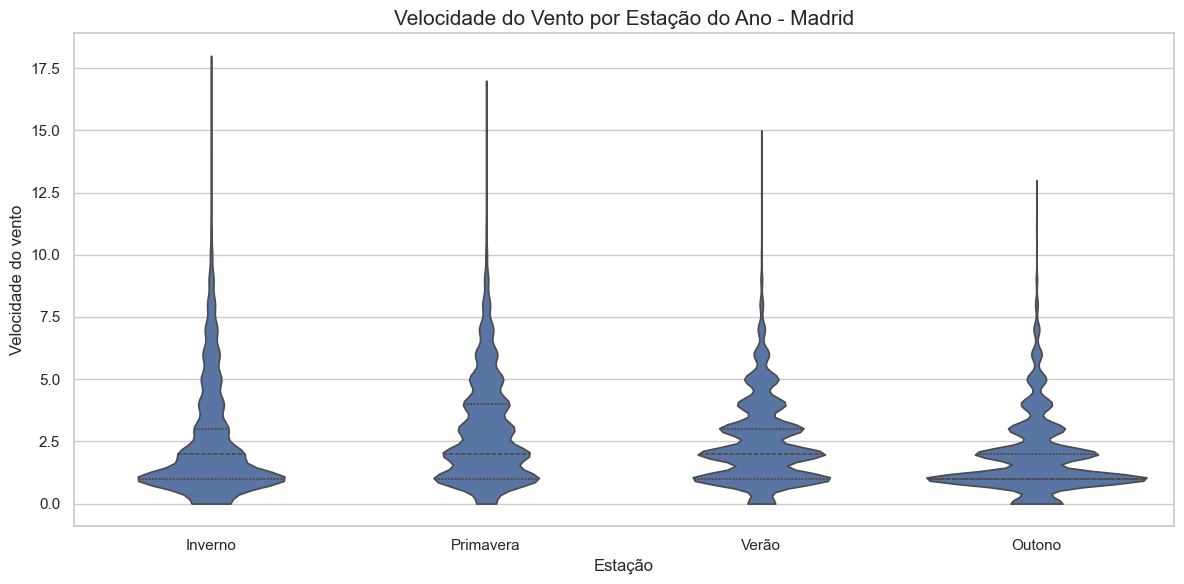

In [56]:
# APENAS MADRID

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_clima_4["dt_iso"] = pd.to_datetime(df_clima_4["dt_iso"], utc=True).dt.tz_convert(None)

df_vento = df_clima_4[["dt_iso", "city_name", "wind_speed"]].copy()
df_vento = df_vento[df_vento["city_name"] == "Madrid"]
df_vento = df_vento.dropna(subset=["wind_speed"])

def definir_estacao(mes):
    if mes in [12, 1, 2]:
        return "Inverno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verão"
    else:
        return "Outono"

df_vento["estacao"] = df_vento["dt_iso"].dt.month.map(
    lambda mes: definir_estacao(mes)
)

ordem_estacoes = ["Inverno", "Primavera", "Verão", "Outono"]

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_vento,
    x="estacao",
    y="wind_speed",
    order=ordem_estacoes,
    inner="quartile",
    cut=0
)

plt.title("Velocidade do Vento por Estação do Ano - Madrid", fontsize=15)
plt.xlabel("Estação")
plt.ylabel("Velocidade do vento")
plt.tight_layout()

# Gerando o nome do arquivo para salvamento
filename = f"4.6_violin_plot_vento.svg"
filepath = os.path.join(folder, filename)

# Salvando (sempre antes do plt.show())
plt.savefig(filepath, format='svg')

plt.show()

<div style="color: green;">

## 5. Correlação, causalidade

<div style="color: green;">

O trabalho foca na relação entre geração de energia, demanda (carga total), condições climáticas e preços na Espanha (2014-2018).

Análise de Correlação


    Carga Total vs. Temperatura: Existe uma correlação esperada entre a demanda de energia e a temperatura das cidades. Em picos de temperatura (verão/inverno), a carga tende a aumentar devido ao uso de sistemas de climatização.

    Fontes Renováveis vs. Preço: O dataset permite correlacionar a geração solar e eólica com o "price actual". Geralmente, uma maior oferta de renováveis (especialmente eólica) correlaciona-se com a queda do preço marginal da energia.

    Geração vs. Demanda: Há uma correlação direta entre a "total load actual" (carga real) e a soma das gerações de diferentes fontes (gás, carvão, hidro, etc.), uma vez que o sistema deve ser equilibrado em tempo real.

Análise de Causalidade

Diferente da correlação (que apenas indica que variáveis mudam juntas), a causalidade implica que uma variável influencia diretamente a outra:

    Fatores Climáticos como Causa: As condições climáticas (temperatura, velocidade do vento) são causas para a variação na geração e na demanda. Por exemplo:

O aumento da velocidade do vento causa diretamente o aumento na "generation wind onshore", que é a geração éolica.

O aumento de temperatura causa diretamente o aumento na "gerneration solar", que é a gereção solar.

Custos de Geração e Preço: O tipo de fonte despachada causa impacto no preço. Fontes com maior custo marginal (como "generation fossil gas") quando acionadas para suprir picos de carga, causam o aumento do preço da energia no mercado.

<div style="color: red;">

# 5.	Fechamento conceitual ligado a aprendizado de máquina

<div style="color: red;">

Esta base pode ser usada em mais de uma formulação de aprendizado de máquina:

- regressão: prever a demanda ou a geração de alguma fonte específica (como a solar, por exemplo) em instantes futuros dadas as condições climáticas;
- classificação: prever a carga quando há ocorrência de neve;
- séries temporais: previsão de carga horária, diária ou semanal;
- detecção de anomalias: identificar a ocorrência de eventos climáticos extremos, como ondas de calor ou volumes anormais de neve.

## Formulação possível para T2

Seria interessante e possível prever **a demanda total hora hora do dia seguinte** com base nos dados de geração e de condições climáticas, o que caracteriza um problema de regressão com forte componente temporal.

### Desafios esperados

- dependência temporal entre observações;
- sazonalidade diária, semanal e mensal;
- possíveis relações não lineares entre as variáveis, em especial com relação às variáveis climáticas.

<div style="color: green;">

# 6. Conclusão — Parte 1

<div style="color: green;">

A análise realizada ao longo deste trabalho permitiu uma compreensão da dinâmica do setor elétrico espanhol durante o período de quatro anos estudado. Através da aplicação de ferramentas de data science em Python, foi possível observar que:

- Interdependência de Variáveis: A correlação de Pearson confirmou a influência direta das condições meteorológicas (temperatura e umidade) sobre a carga total do sistema. O aumento da demanda em picos térmicos reflete o comportamento típico de consumo para climatização, impactando a volatilidade dos preços de mercado.

- Composição da Matriz: A visualização da geração por fonte revelou o papel estratégico das energias renováveis (solar e eólica) na matriz energética. Observou-se que, em períodos de alta geração renovável, há uma tendência de redução no custo marginal da energia, embora a dependência de fontes despacháveis, como o gás, ainda seja determinante para a estabilidade do sistema em momentos de baixa produção natural.

- Validação Estatística: A análise de histograma foi fundamental para determinar a natureza da distribuição dos dados. A constatação de que a demanda e os preços muitas vezes não seguem uma distribuição normal justifica a necessidade de métodos estatísticos mais robustos para previsões de carga e planejamento operativo.

- Papel das energias de Base Vs Intermitentes: Ficou evidente que, enquanto a energia nuclear atua como uma base estável e constante, as fontes solar e eólica introduzem uma variabilidade que precisa ser compensada pelo gás (ciclo combinado). A conclusão aponta que a flexibilidade das centrais a gás ainda é o "seguro" do sistema para garantir o suprimento quando a meteorologia não é favorável.

### Referências Bibliográficas

KUHN, M.; JOHNSON, K. **Feature Engineering and Selection**: A Practical Approach for Predictive Models. Boca Raton: CRC Press, 2019.